# Objetivos:
## mapeamento da sazonalidade de fluxo de turistas, identificando mercados internacionais prioritários. Assim, classificar destinos por período do ano e nacionalidade, ajudando a direcionar campanhas de promoção turística para países com maior potencial de enviar turistas, ou ainda países com maior potencial de crescimento nesta questão.

In [1]:
#!pip install matplotlib seaborn pandas streamlit --break-system-packages 

In [2]:
%matplotlib inline
import os
import math
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

In [3]:
#BASE_DATA_FOLDER = os.path.join(".", "base_data")
BASE_DATA_FOLDER = os.path.join("/","kaggle", "input", "data-trabalho")

In [4]:
def read_csv(file:str) -> pd.DataFrame:
    ENCODING="windows-1252"
    SEP=";"
    return pd.read_csv(file, encoding=ENCODING, sep=SEP)

In [5]:
def concat_path(file:str) -> str:
    return os.path.join(BASE_DATA_FOLDER, file)

In [6]:
csv_files = sorted(list(filter(lambda file: 'csv' in file, [concat_path(file)  for file in os.listdir(path=BASE_DATA_FOLDER)])))
csv_files

['/kaggle/input/data-trabalho/base_chegadas_2025_acum_08_agosto.csv',
 '/kaggle/input/data-trabalho/chegadas_2023.csv',
 '/kaggle/input/data-trabalho/chegadas_2024.csv']

In [7]:
data_2025 = read_csv(csv_files[0])
data_2025.head()

,Via_de_acesso,UF,nome_pais_correto,mes,ano,Chegadas
0,Aérea,Rio de Janeiro,Afeganistão,Janeiro,2025,1
1,Aérea,São Paulo,Afeganistão,Janeiro,2025,3
2,Terrestre,Paraná,Afeganistão,Janeiro,2025,2
3,Terrestre,Santa Catarina,Afeganistão,Janeiro,2025,4
4,Terrestre,Santa Catarina,Afeganistão,Janeiro,2025,2


In [8]:
data_2023 = read_csv(csv_files[1])
data_2023.head()

,Continente,cod continente,País,cod pais,UF,cod uf,Via,cod via,ano,Mês,cod mes,Chegadas
0,América do Sul,4,Peru,34,Acre,1,Aéreo,1,2023,Novembro,11,0
1,América do Sul,4,Peru,34,Acre,1,Aéreo,1,2023,Novembro,11,0
2,Ásia,5,Outros países,56,Outras Unidades da Federação,99,Aéreo,1,2023,Junho,6,0
3,Europa,6,Alemanha,57,Outras Unidades da Federação,99,Aéreo,1,2023,Janeiro,1,12
4,Europa,6,Alemanha,57,Outras Unidades da Federação,99,Aéreo,1,2023,Fevereiro,2,10


In [9]:
data_2024 = read_csv(csv_files[-1])
data_2024.head()

,Continente,cod continente,País,cod pais,UF,cod uf,Via,cod via,ano,Mês,cod mes,Chegadas
0,Europa,6,Alemanha,57,Outras Unidades da Federação,99,Aérea,1,2024,Janeiro,1,10
1,América do Sul,4,Argentina,26,Outras Unidades da Federação,99,Aérea,1,2024,Janeiro,1,1197
2,Europa,6,Bélgica,59,Outras Unidades da Federação,99,Aérea,1,2024,Janeiro,1,3
3,América do Norte,3,Canadá,23,Outras Unidades da Federação,99,Aérea,1,2024,Janeiro,1,2
4,América do Sul,4,Chile,28,Outras Unidades da Federação,99,Aérea,1,2024,Janeiro,1,1


# LIMPEZA E CONSOLIDAÇÃO DOS DADOS

In [10]:
# definindo os valores  de continentes para cada país individual
countries_continents_2024 = data_2024[["Continente","País"]]
countries_continents_2023 = data_2023[["Continente","País"]]

matching_continets_per_country = pd.concat([countries_continents_2024,countries_continents_2023],axis=0)
print("Before=%d"%(matching_continets_per_country.shape[0]))
matching_continets_per_country.drop_duplicates(inplace=True, keep="first")
print("After=%d"%(matching_continets_per_country.shape[0]))
matching_continets_per_country.head()

Before=57620
After=98


,Continente,País
0,Europa,Alemanha
1,América do Sul,Argentina
2,Europa,Bélgica
3,América do Norte,Canadá
4,América do Sul,Chile


In [11]:
data_2025 = data_2025.rename({"nome_pais_correto":"País"}, axis='columns')
data_2025.head()

,Via_de_acesso,UF,País,mes,ano,Chegadas
0,Aérea,Rio de Janeiro,Afeganistão,Janeiro,2025,1
1,Aérea,São Paulo,Afeganistão,Janeiro,2025,3
2,Terrestre,Paraná,Afeganistão,Janeiro,2025,2
3,Terrestre,Santa Catarina,Afeganistão,Janeiro,2025,4
4,Terrestre,Santa Catarina,Afeganistão,Janeiro,2025,2


In [12]:
display(matching_continets_per_country[matching_continets_per_country["País"].duplicated(keep=False)])
matching_continets_per_country.drop(matching_continets_per_country[matching_continets_per_country["País"] == "Outros países"].index, inplace=True)
matching_continets_per_country[matching_continets_per_country["País"].duplicated(keep=False)]

,Continente,País
2,Ásia,Outros países
48,Europa,Outros países
125,África,Outros países
207,América Central e Caribe,Outros países
4299,Oceania,Outros países


,Continente,País


In [13]:
print(f"Data 2025 total rows(empty): {data_2025.shape[0]}")
data_2025["Continente"] = data_2025["País"].map(matching_continets_per_country.set_index('País')['Continente'])
print(f"Data 2025 total rows with NaN: {data_2025['Continente'].isna().sum()}")
data_2025.head()

Data 2025 total rows(empty): 16271
Data 2025 total rows with NaN: 2789


,Via_de_acesso,UF,País,mes,ano,Chegadas,Continente
0,Aérea,Rio de Janeiro,Afeganistão,Janeiro,2025,1,NaN
1,Aérea,São Paulo,Afeganistão,Janeiro,2025,3,NaN
2,Terrestre,Paraná,Afeganistão,Janeiro,2025,2,NaN
3,Terrestre,Santa Catarina,Afeganistão,Janeiro,2025,4,NaN
4,Terrestre,Santa Catarina,Afeganistão,Janeiro,2025,2,NaN


In [14]:
print("Countries that are not contained inside the matching list:")
data_2025[~data_2025["País"].isin(matching_continets_per_country["País"])]["País"].unique()

Countries that are not contained inside the matching list:


array(['Afeganistão', 'Albânia', 'Andorra', 'Antilhas Holandesas',
       'Antígua e Barbuda', 'Argélia', 'Armênia', 'Azerbaijão', 'Bahamas',
       'Barbados', 'Barein', 'Belize', 'Benin', 'Bielorússia', 'Botsuana',
       'Burkina Faso', 'Burundi', 'Butão', 'Bélgica',
       'Bósnia-Herzegovina', 'Camarões', 'Camboja', 'Casaquistão',
       'Catar', 'Chade', 'China, Macao', 'Chipre', 'Congo',
       'Costa do Marfim', 'Dominica', 'Emirados Árabes Unidos',
       'Eritréia', 'Etiópia', 'Fiji', 'Gabão', 'Geórgia', 'Granada',
       'Guiné', 'Guiné Equatorial', 'Guiné-Bissau', 'Gâmbia', 'Honduras',
       'Iraque', 'Islândia', 'Iêmen', 'Jamaica', 'Jordânia', 'Kuwait',
       'Libéria', 'Liechtenstein', 'Líbia', 'Macedônia', 'Madagascar',
       'Malauí', 'Maldivas', 'Mali', 'Malta', 'Mauritânia', 'Maurício',
       'Mianma', 'Moldávia', 'Mongólia', 'Montenegro', 'Mônaco',
       'Namíbia', 'Nepal', 'Omã', 'Palestina', 'Papua Nova Guiné',
       'Porto Rico', 'Quirguistão', 'República Ce

In [15]:
data_2023["Continente"].unique(), data_2024["Continente"].unique()

(array(['América do Sul', 'Ásia', 'Europa', 'Oceania', 'África',
        'América do Norte', 'América Central e Caribe',
        'Continente não especificado'], dtype=object),
 array(['Europa', 'América do Sul', 'América do Norte', 'África',
        'Oceania', 'América Central e Caribe', 'Ásia',
        'Continente não especificado'], dtype=object))

In [16]:
# Corrigindo os valores faltantes de data_2025
data_2025["Continente"] = data_2025["Continente"].fillna("Continente não especificado")
display(data_2025.head())
data_2025["Continente"].unique()

,Via_de_acesso,UF,País,mes,ano,Chegadas,Continente
0,Aérea,Rio de Janeiro,Afeganistão,Janeiro,2025,1,Continente não especificado
1,Aérea,São Paulo,Afeganistão,Janeiro,2025,3,Continente não especificado
2,Terrestre,Paraná,Afeganistão,Janeiro,2025,2,Continente não especificado
3,Terrestre,Santa Catarina,Afeganistão,Janeiro,2025,4,Continente não especificado
4,Terrestre,Santa Catarina,Afeganistão,Janeiro,2025,2,Continente não especificado


array(['Continente não especificado', 'Europa', 'África',
       'América do Sul', 'Ásia', 'Oceania', 'América do Norte',
       'América Central e Caribe'], dtype=object)

In [17]:
#Consolidação
columns_to_drop = ["cod uf", "cod continente", "cod mes", "cod pais", "cod via"]
rename_columns = {"Via_de_acesso":"Via", "nome_pais_correto":"País", "Mês":"mes"}

data = pd.DataFrame()

for csv_file in [data_2023, data_2024, data_2025]:
    try:
        csv_file.drop(columns_to_drop,inplace=True,axis=1)
    except KeyError:
        pass

    csv_file.rename(rename_columns,inplace=True,axis="columns")

    data = pd.concat([data,csv_file],axis=0,ignore_index=True)

data.to_csv("all_data.csv",index=False)
data.head()

,Continente,País,UF,Via,ano,mes,Chegadas
0,América do Sul,Peru,Acre,Aéreo,2023,Novembro,0
1,América do Sul,Peru,Acre,Aéreo,2023,Novembro,0
2,Ásia,Outros países,Outras Unidades da Federação,Aéreo,2023,Junho,0
3,Europa,Alemanha,Outras Unidades da Federação,Aéreo,2023,Janeiro,12
4,Europa,Alemanha,Outras Unidades da Federação,Aéreo,2023,Fevereiro,10


In [18]:
data.isna().sum()

Continente    0
País          0
UF            0
Via           0
ano           0
mes           0
Chegadas      0
dtype: int64

In [19]:
data.isnull().sum()

Continente    0
País          0
UF            0
Via           0
ano           0
mes           0
Chegadas      0
dtype: int64

In [20]:
data_2023.shape, data_2024.shape, data_2025.shape, data.shape

((34764, 7), (22856, 7), (16271, 7), (73891, 7))

In [21]:
data["mes"].unique()

array(['Novembro', 'Junho', 'Janeiro', 'Fevereiro', 'Marco', 'Abril',
       'Maio', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Dezembro',
       'Março'], dtype=object)

In [22]:
data.loc[data.mes == "Março","mes"] = "Marco"
data["mes"].unique()

array(['Novembro', 'Junho', 'Janeiro', 'Fevereiro', 'Marco', 'Abril',
       'Maio', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Dezembro'],
      dtype=object)

In [23]:
data["Via"].unique()

array(['Aéreo', 'Terrestre', 'Marítimo', 'Fluvial', 'Aérea', 'Marítima'],
      dtype=object)

In [24]:
data.loc[data.Via == "Aéreo","Via"] = "Aérea"
data.loc[data.Via == "Marítimo","Via"] = "Marítima"
data["Via"].unique()

array(['Aérea', 'Terrestre', 'Marítima', 'Fluvial'], dtype=object)

In [25]:
data.describe()

,ano,Chegadas
count,73891.000000,73891.000000
mean,2023.749726,259.981094
std,0.792497,2624.627030
min,2023.000000,0.000000
25%,2023.000000,1.000000
50%,2024.000000,3.000000
75%,2024.000000,16.000000
max,2025.000000,261100.000000


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73891 entries, 0 to 73890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Continente  73891 non-null  object
 1   País        73891 non-null  object
 2   UF          73891 non-null  object
 3   Via         73891 non-null  object
 4   ano         73891 non-null  int64 
 5   mes         73891 non-null  object
 6   Chegadas    73891 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 3.9+ MB


# Análise 

In [27]:
data_grouped = data.groupby(["mes", "País", "ano"])["Chegadas"].sum()
data_grouped

mes       País           ano 
Abril     Afeganistão    2025       13
          Albânia        2025       45
          Alemanha       2023    11005
                         2024    11851
                         2025    16262
                                 ...  
Setembro  África do Sul  2024     1362
          Áustria        2023     1146
                         2024     1179
          Índia          2023     1283
                         2024     1464
Name: Chegadas, Length: 3639, dtype: int64

In [28]:
display(data.describe())

first_split = data[data["Chegadas"] > 16]
print("Primeira divisão pelos 75%")
display(first_split.describe())

second_split = first_split[first_split["Chegadas"] > 396]
print("Segunda divisão pelos 75%")
display(second_split.describe())

third_split = second_split[second_split["Chegadas"] > 1220]
print("Terceira divisão pelos 50%")
display(third_split.describe())

,ano,Chegadas
count,73891.000000,73891.000000
mean,2023.749726,259.981094
std,0.792497,2624.627030
min,2023.000000,0.000000
25%,2023.000000,1.000000
50%,2024.000000,3.000000
75%,2024.000000,16.000000
max,2025.000000,261100.000000


Primeira divisão pelos 75%


,ano,Chegadas
count,18360.000000,18360.000000
mean,2023.931155,1037.489488
std,0.789073,5188.501304
min,2023.000000,17.000000
25%,2023.000000,34.000000
50%,2024.000000,94.000000
75%,2025.000000,396.250000
max,2025.000000,261100.000000


Segunda divisão pelos 75%


,ano,Chegadas
count,4590.000000,4590.000000
mean,2023.947712,3869.070588
std,0.783832,9847.964534
min,2023.000000,397.000000
25%,2023.000000,646.250000
50%,2024.000000,1220.000000
75%,2025.000000,3187.250000
max,2025.000000,261100.000000


Terceira divisão pelos 50%


,ano,Chegadas
count,2294.000000,2294.000000
mean,2023.976024,7035.948561
std,0.789067,13190.126258
min,2023.000000,1221.000000
25%,2023.000000,1816.000000
50%,2024.000000,3188.500000
75%,2025.000000,6272.750000
max,2025.000000,261100.000000


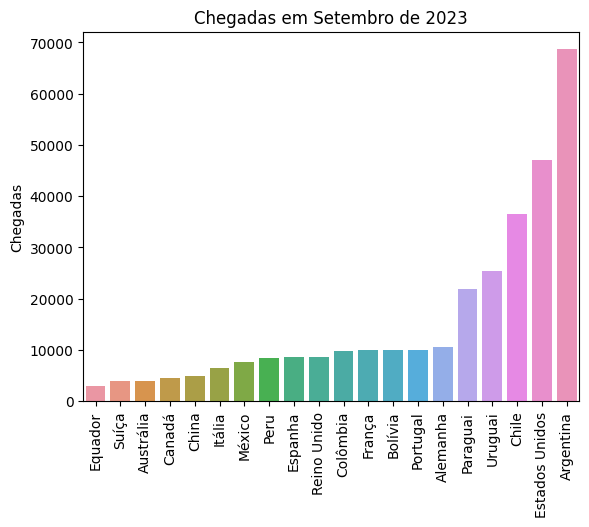

In [29]:
september = data_grouped.loc["Setembro"]
september_df = pd.DataFrame(september).reset_index()
part = september_df[(september_df["ano"] == 2023) & (september_df["Chegadas"] > 3000)]
part = part.sort_values(by="Chegadas")
sns.barplot(data=part, x="País", y="Chegadas")
plt.xticks(rotation=90)
plt.xlabel("")
plt.title("Chegadas em Setembro de 2023")
plt.show()

In [30]:
months = ["Janeiro", "Fevereiro", "Marco", "Abril", "Maio", "Junho", "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"]

In [31]:
def plot_by_year_and_criteria(year, criteria=5000):
    fig,ax = plt.subplots(3,4,figsize=(40,50))
    current_month = 0
    
    plt.suptitle(f"Chegadas {year} > {criteria}", fontsize=30, y=0.9)
    
    for i in range(3):
        for j in range(4):
            month = months[current_month]
            curr_ax = ax[i,j]
            part_data_grouped = data_grouped.loc[month]
            part_data = pd.DataFrame(part_data_grouped).reset_index()
            
            part_data_filtered = part_data[(part_data["ano"] == year) & (part_data["Chegadas"] > criteria)]
            
            if(part_data_filtered.shape[0] <= 0):
                part_data_filtered = part_data[part_data["ano"] == year]     
                
            if(part_data_filtered.shape[0] <= 0):
                current_month += 1
                continue


            part_data_filtered = part_data_filtered.sort_values(by="Chegadas")

            sns.barplot(data=part_data_filtered, x="País", y="Chegadas", ax=curr_ax)
            curr_ax.set_title(month, fontsize=20)
            curr_ax.set_xticklabels(curr_ax.get_xticklabels(), rotation=90, fontsize=16)
            curr_ax.set_xlabel("")
            current_month += 1
            
            

    plt.show()

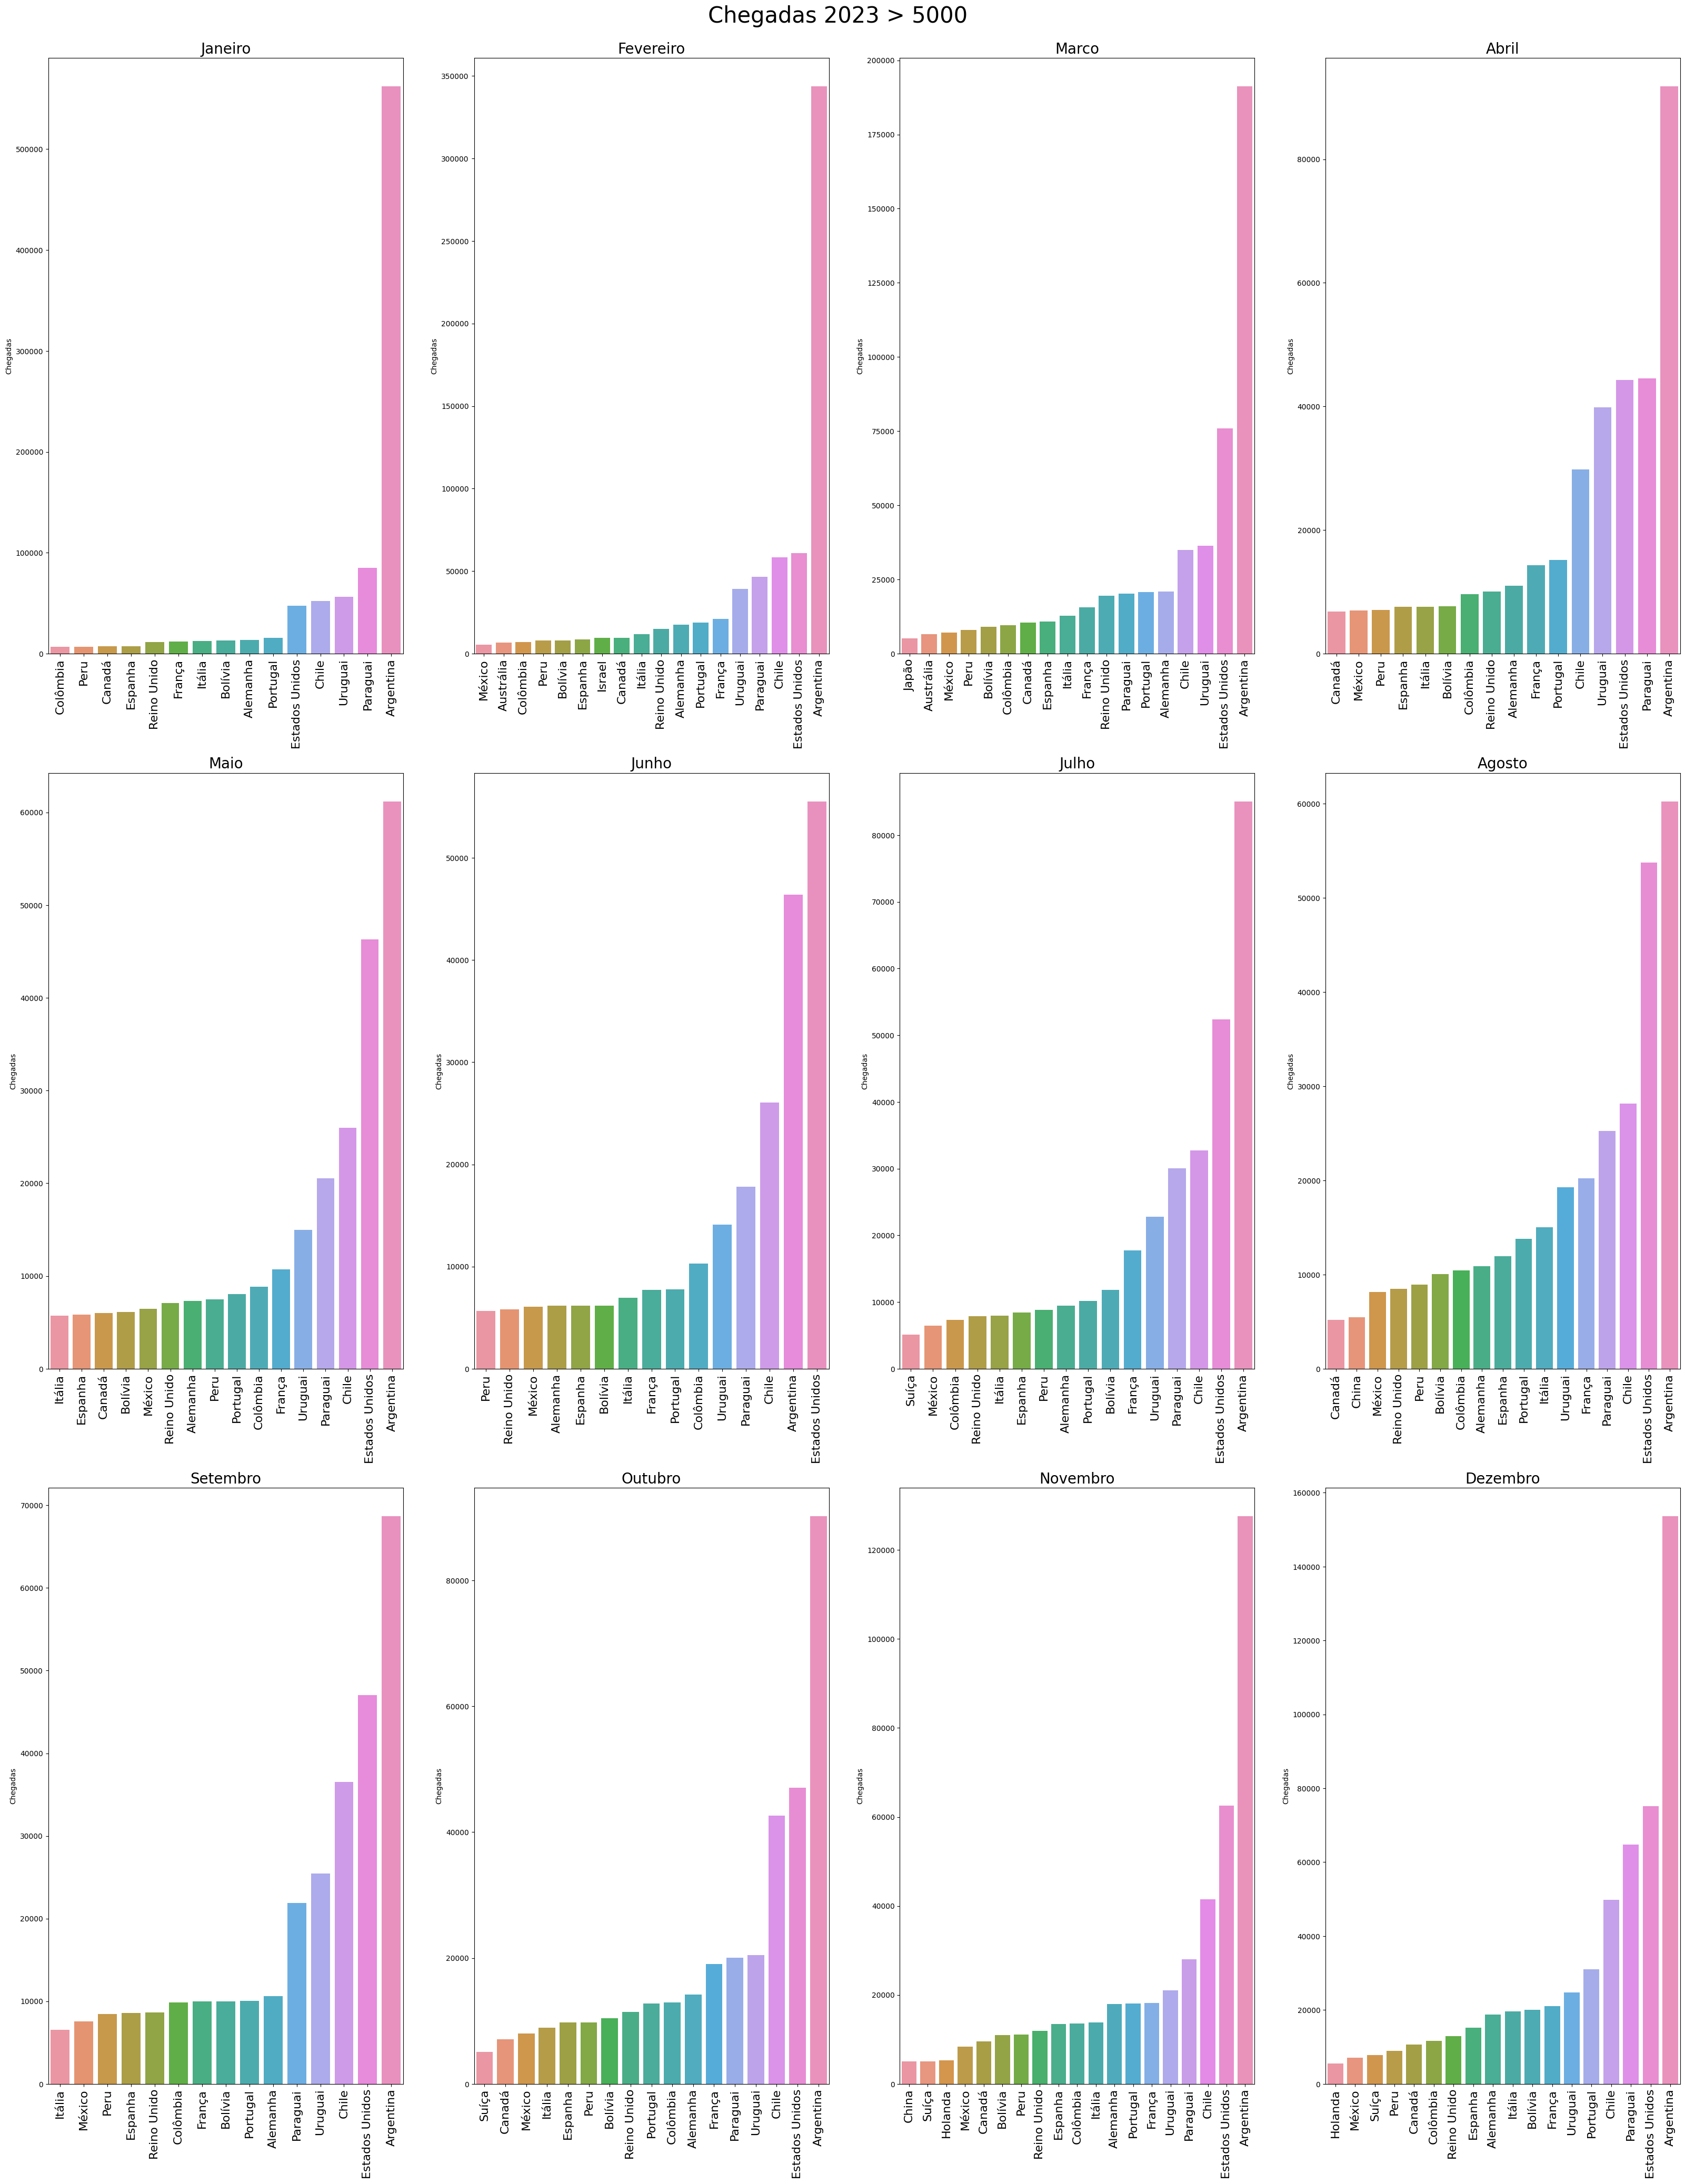

In [32]:
plot_by_year_and_criteria(2023)

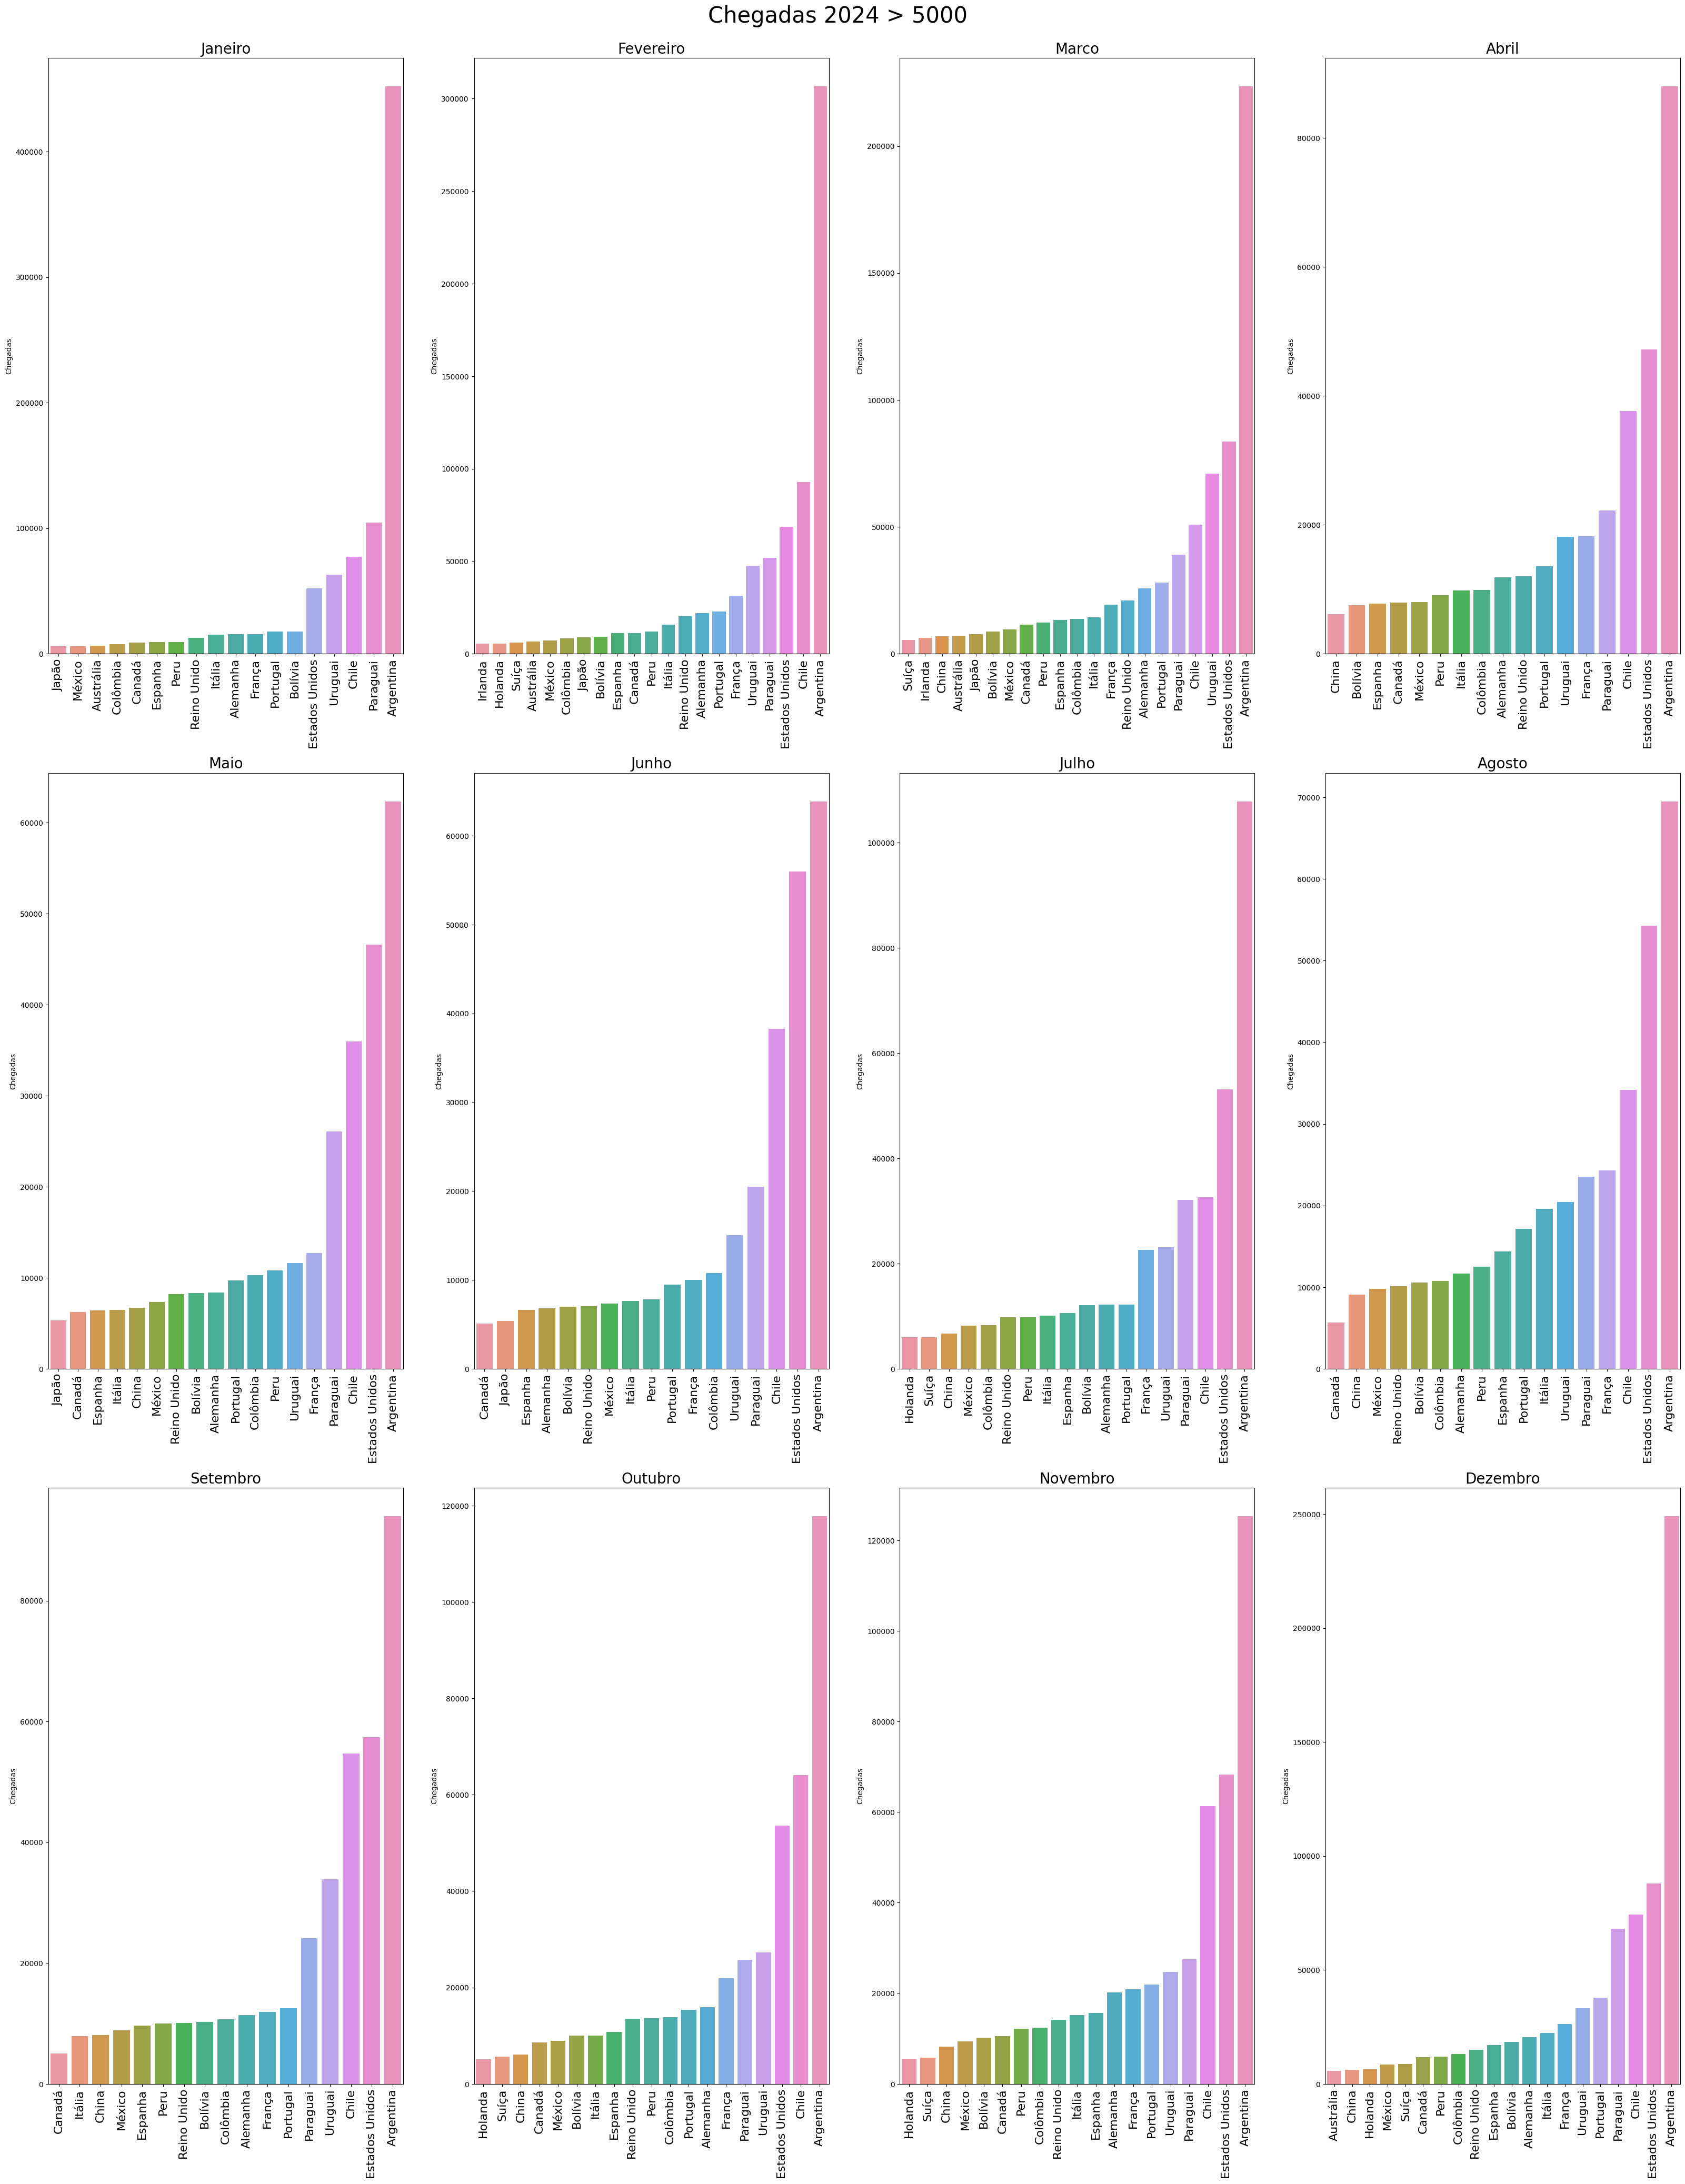

In [33]:
plot_by_year_and_criteria(2024)

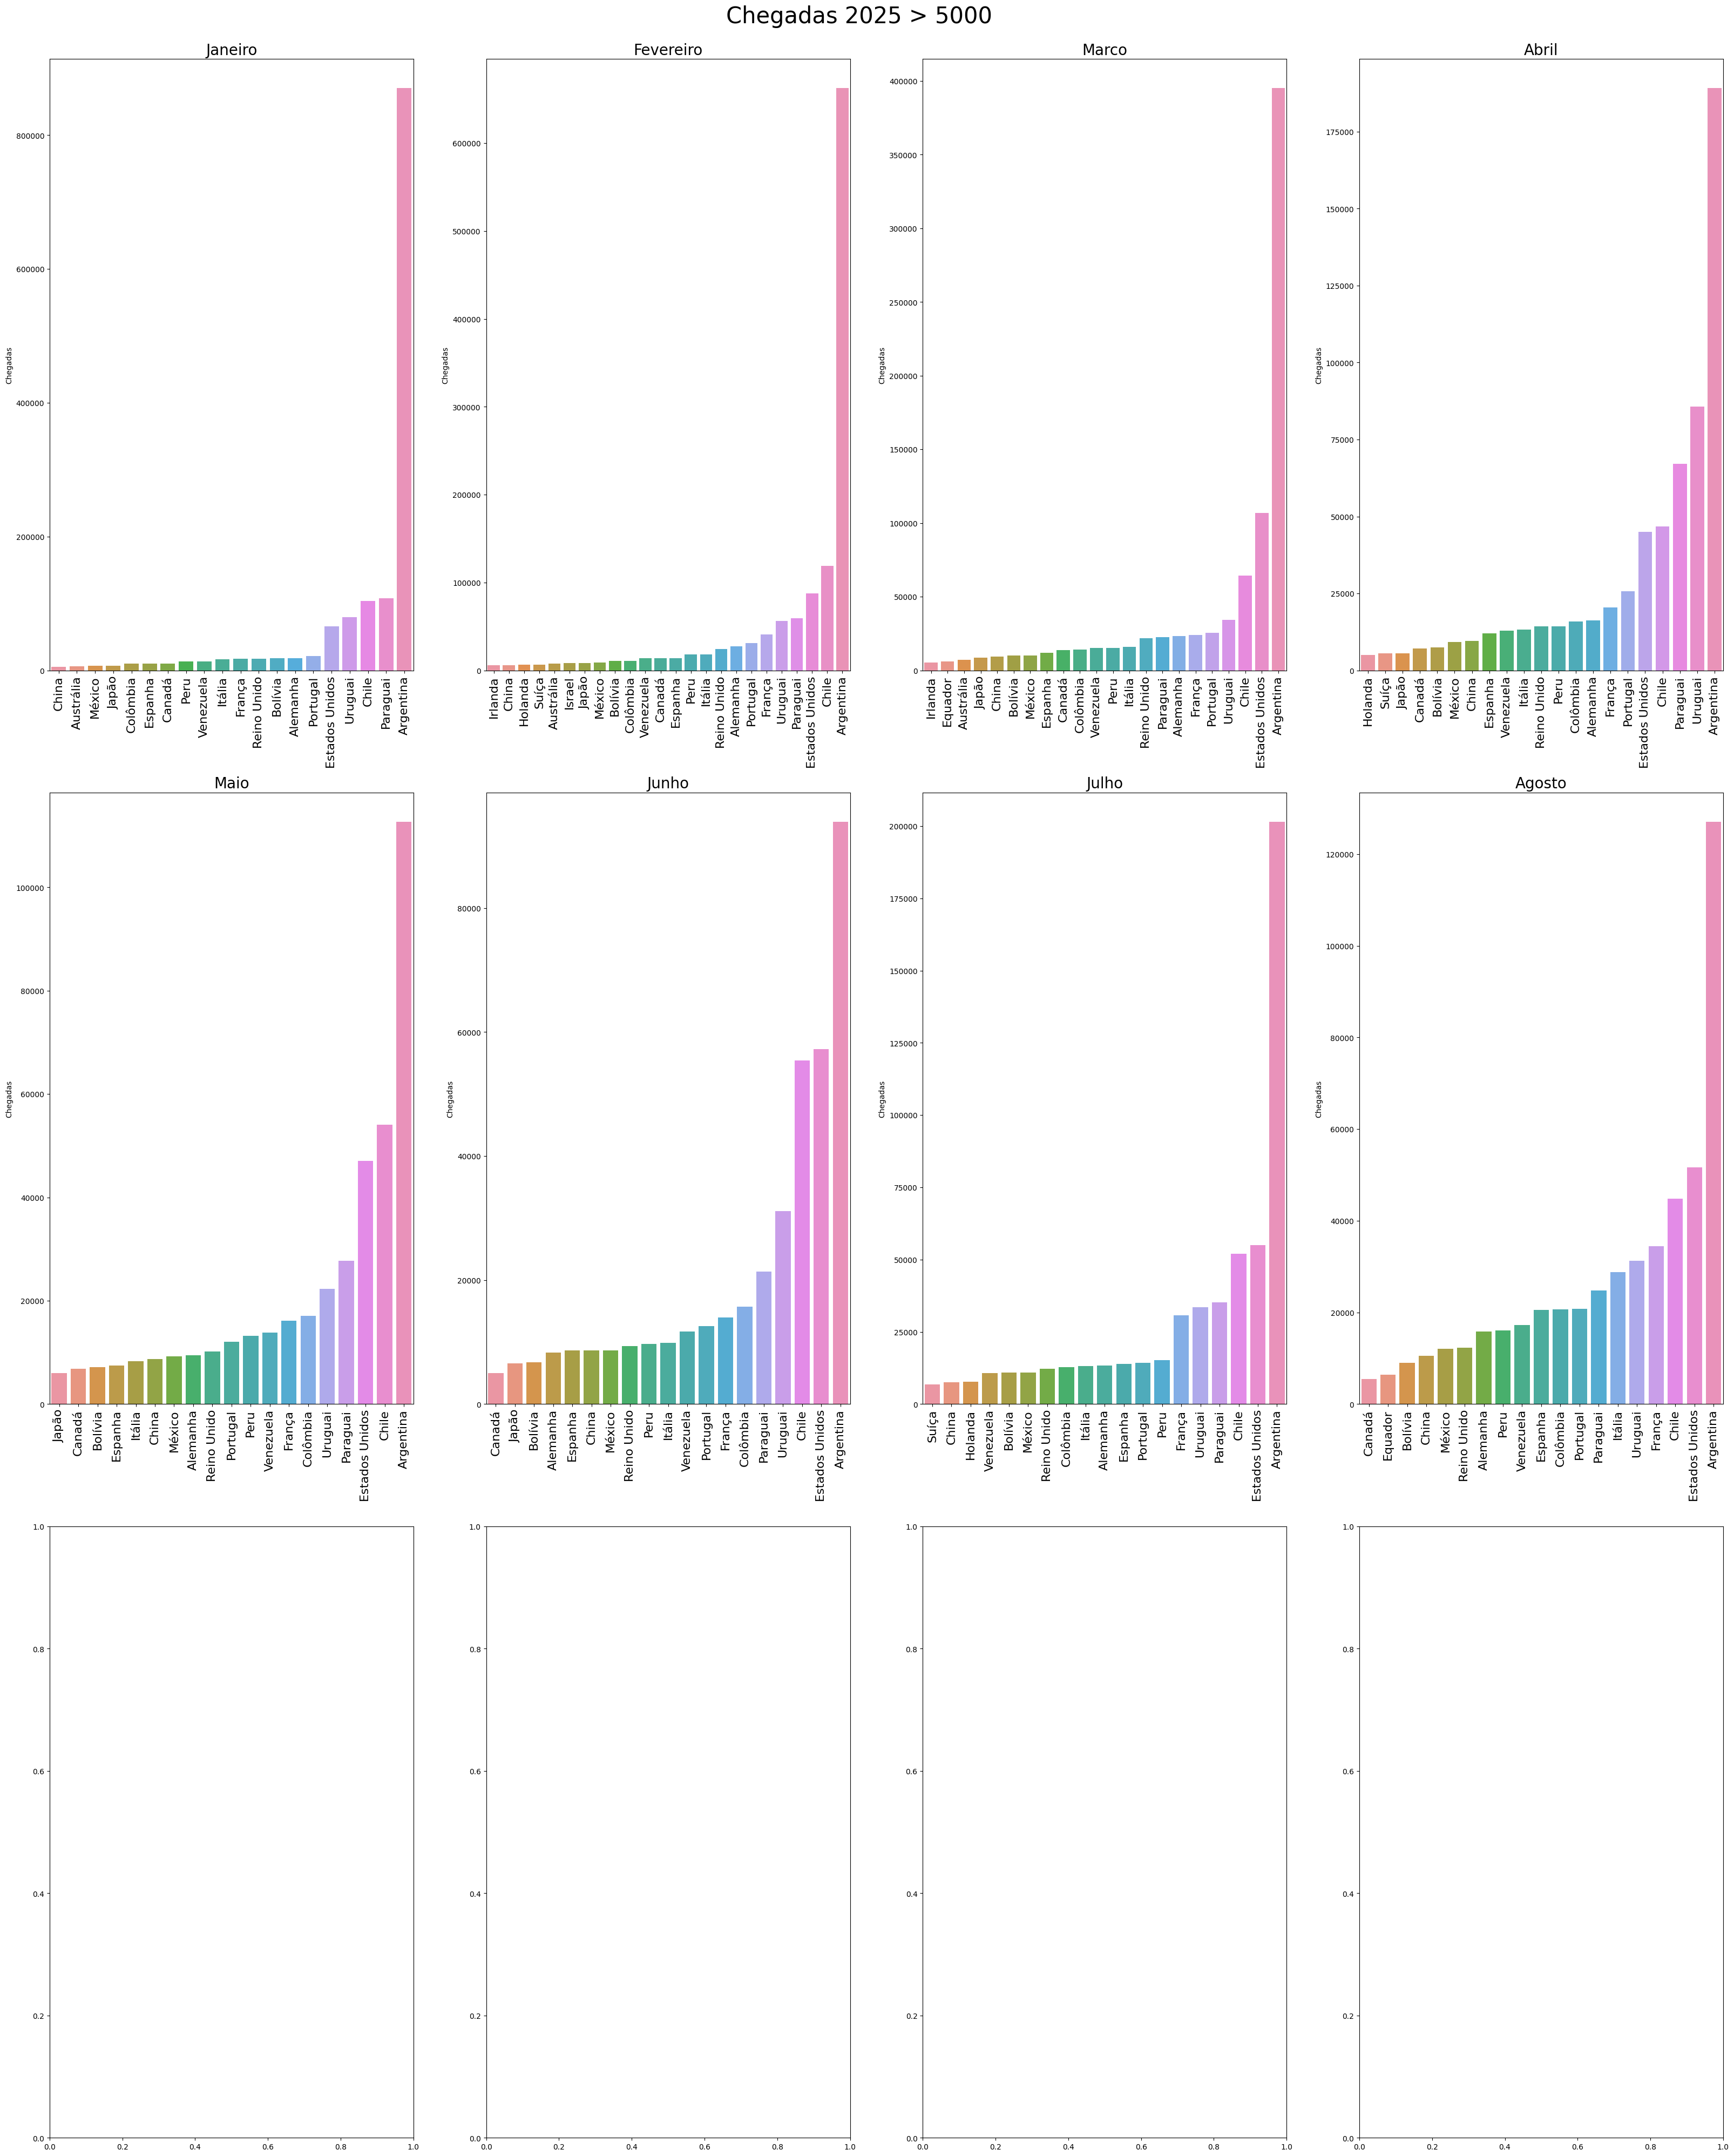

In [34]:
plot_by_year_and_criteria(2025)

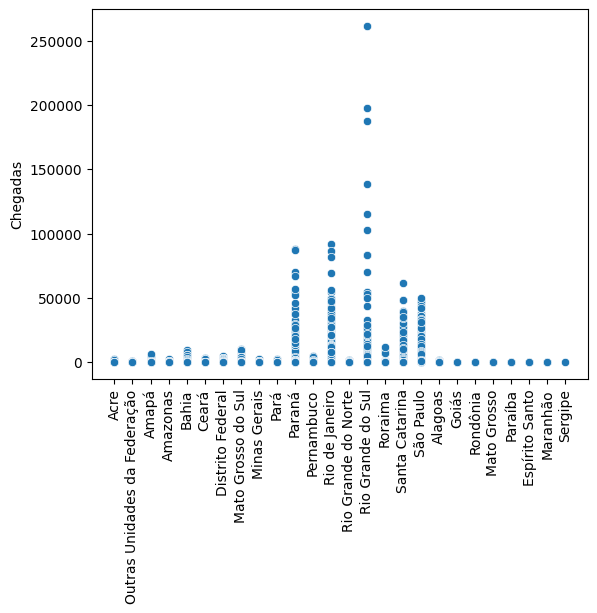

In [35]:
sns.scatterplot(data=data, x="UF",y="Chegadas")
plt.xticks(rotation=90)
plt.xlabel("")
plt.show()

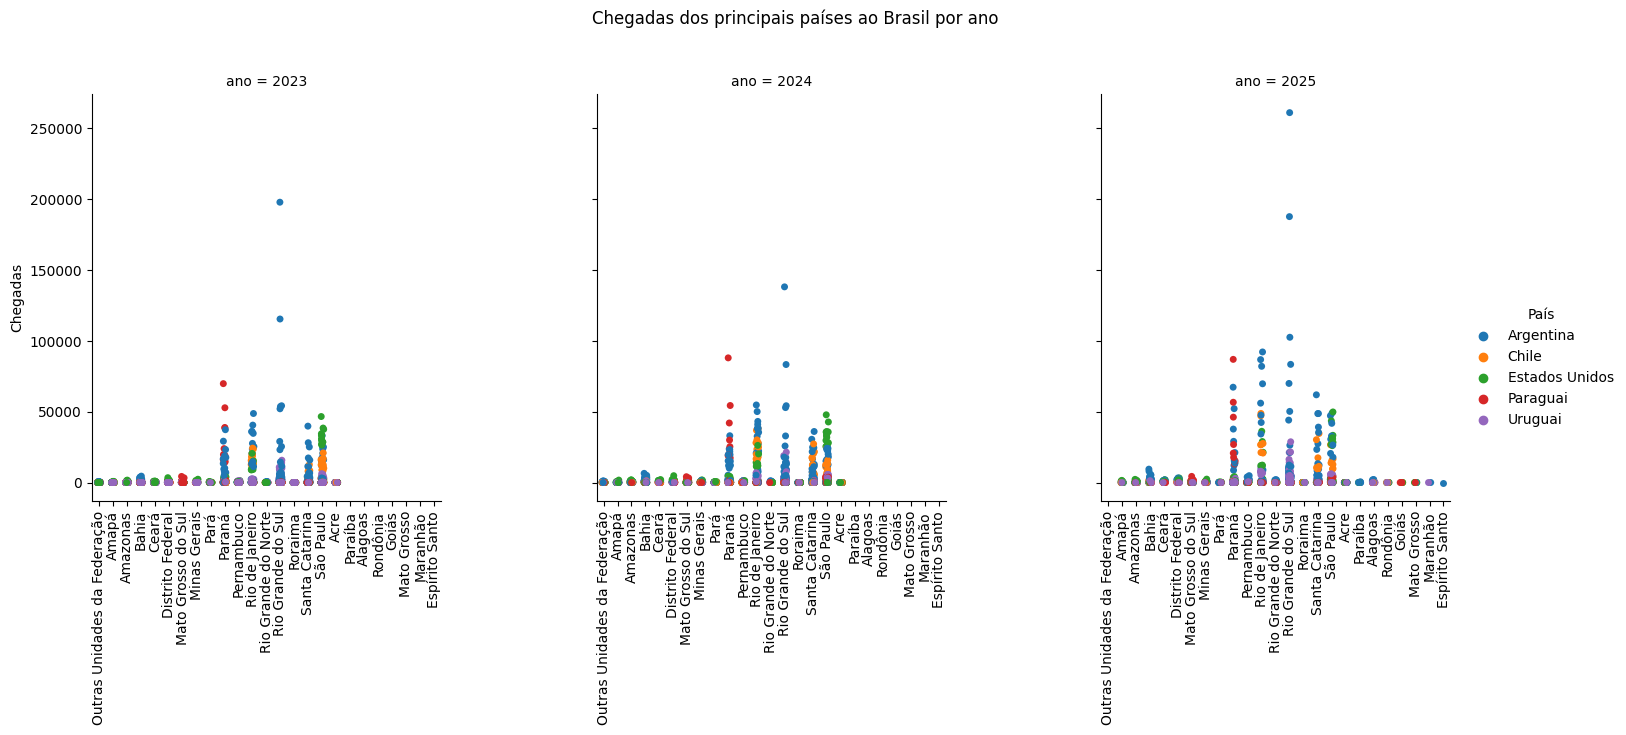

In [36]:
target_countries = ["Argentina", "Chile", "Estados Unidos", "Uruguai", "Paraguai"]
data_for_selected_countries = data[data["País"].isin(target_countries)]
g = sns.catplot(data=data_for_selected_countries, x="UF",y="Chegadas",hue="País", col="ano")
g.set_xticklabels(rotation=90)
g.set_axis_labels("","Chegadas")
plt.suptitle("Chegadas dos principais países ao Brasil por ano", y=1.1)
plt.show()

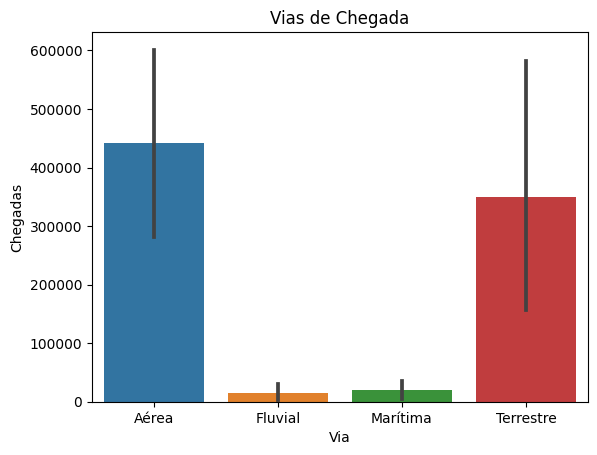

In [37]:
data_grouped = data.groupby(["País", "ano", "Via"])["Chegadas"].sum()
tmp = pd.DataFrame(data_grouped).reset_index()
tmp = tmp[tmp["País"].isin(target_countries)]
sns.barplot(data=tmp, x="Via", y="Chegadas")
plt.title("Vias de Chegada")
plt.show()

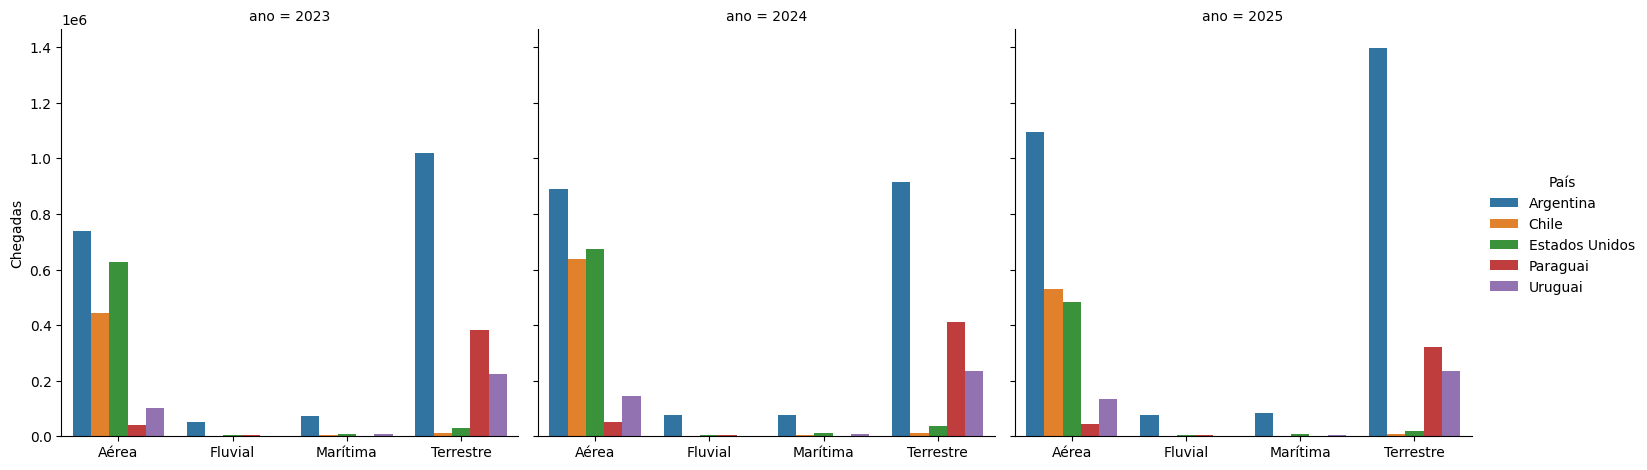

In [38]:
g = sns.catplot(data=tmp, x="Via",y="Chegadas", hue="País", col="ano", kind="bar")
g.set_axis_labels("","Chegadas")
plt.show()

In [39]:
def get_by_via(via,selected_countries=["Argentina", "Paraguai", "Uruguai", "Estados Unidos"]):
    filtered_data = data[(data["País"].isin(selected_countries)) & (data["Via"] == via)]
    grouped = filtered_data.groupby(["País", "UF"])["Chegadas"].sum()
    tmp = pd.DataFrame(grouped).reset_index()
    g = sns.catplot(data=tmp, x="UF", y="Chegadas", kind="bar", col="País")
    g.set_xticklabels(rotation=90)
    g.set_axis_labels("", "Chegadas")
    plt.suptitle(f"Chegadas pela via {via} vindas da Argentina/Paraguai/Uruguai/EUA", y=1.1)
    plt.show()

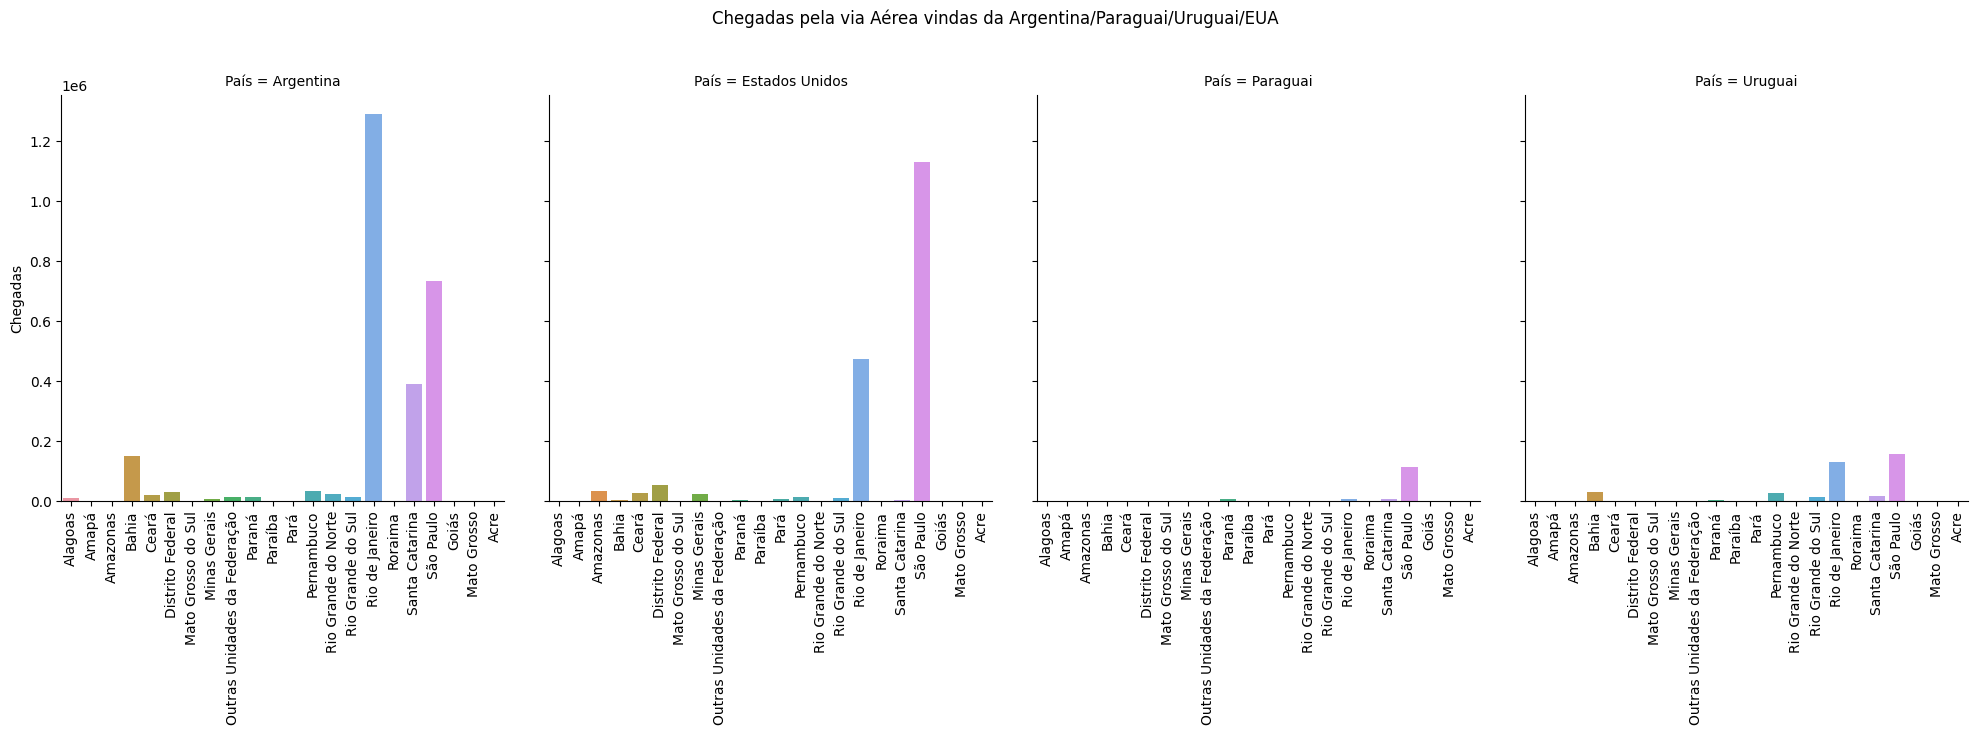

In [40]:
get_by_via("Aérea")

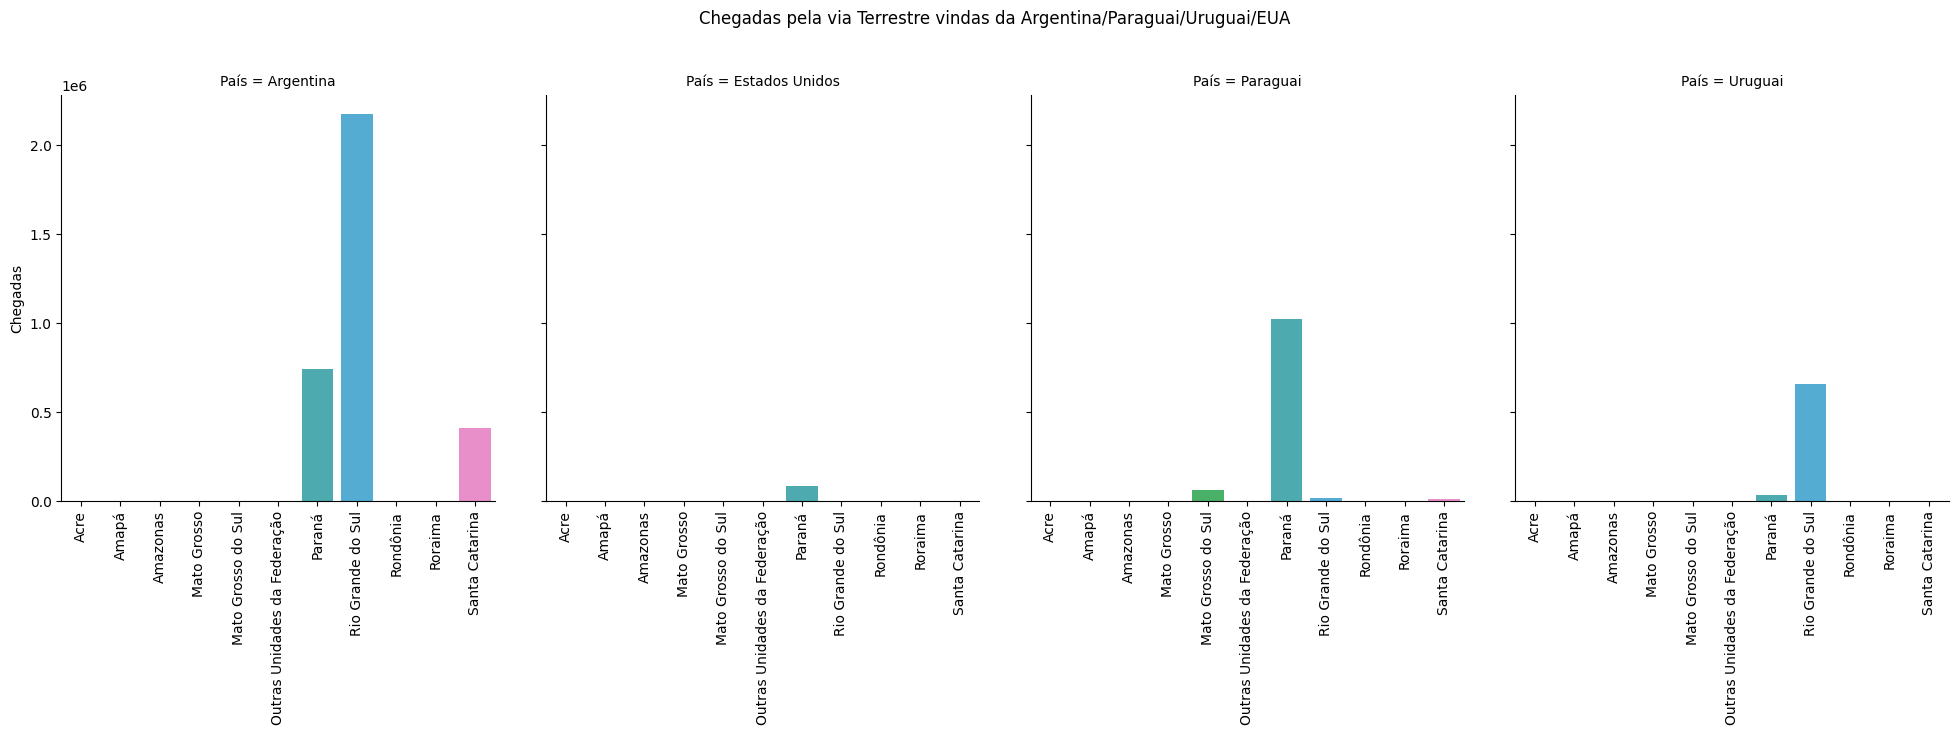

In [41]:
get_by_via("Terrestre")

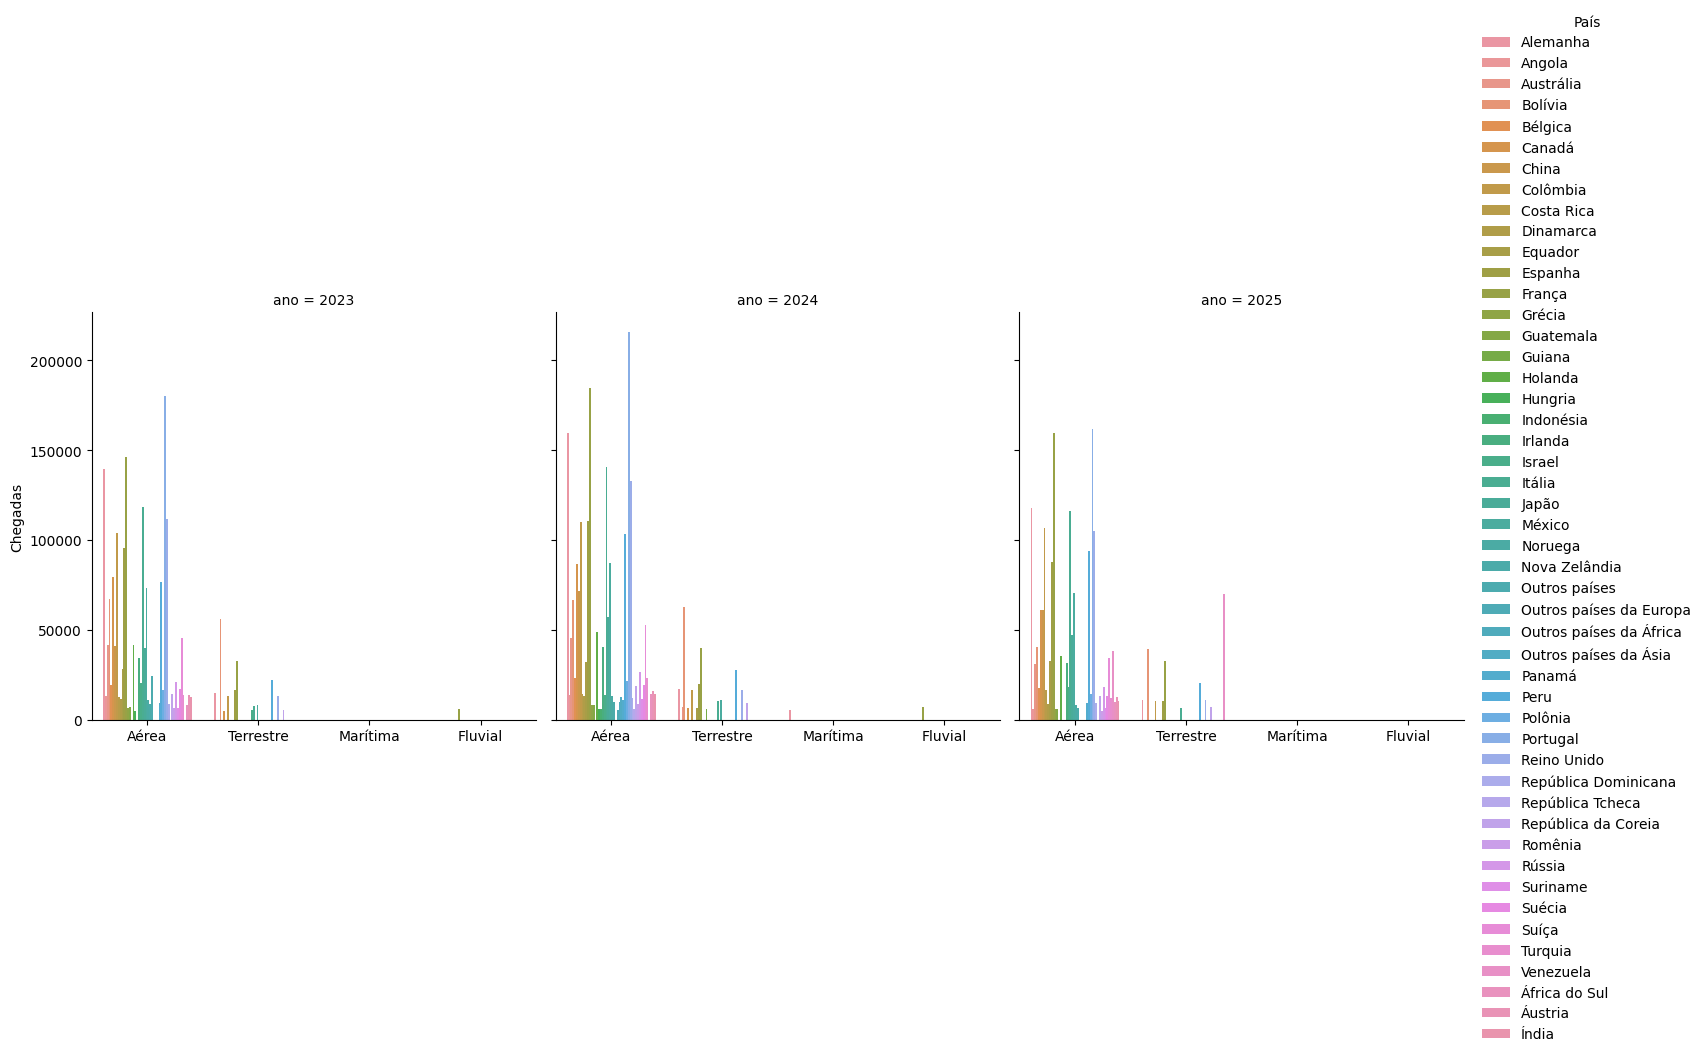

In [42]:
tmp = pd.DataFrame(data_grouped).reset_index()
tmp = tmp[(~tmp["País"].isin(target_countries)) & (tmp["Chegadas"] > 5000)]
g = sns.catplot(data=tmp, x="Via",y="Chegadas", hue="País", col="ano", kind="bar")
g.set_axis_labels("","Chegadas")
plt.show()


- [X] IDENTIFICAR QUAIS PAISES VAO PARA QUAIS REGIOES EM CERTOS MESES
- [X] IDENTIFICAR OUTROS PAISES QUE VAO APRA QUAIS REGIOES EM CERTOS MESES
- [x] FAZER UM GRAFICO DEMONSTRANDO O CRESCIMENTO DO TURISMO EM ALGUMAS REGIOES
- [x] IDENTIFICAR VIAS QUE OUTROS PAISES GOSTAM DE TOMAR PARA VIR PARA O BRASIL

In [43]:
grouped_data = pd.DataFrame(data.groupby(["mes", "País", "UF"])["Chegadas"].sum()).reset_index()
subdata = grouped_data[grouped_data["País"].isin(target_countries)]
subdata.head()

,mes,País,UF,Chegadas
49,Abril,Argentina,Acre,35
50,Abril,Argentina,Alagoas,1059
51,Abril,Argentina,Amapá,8
52,Abril,Argentina,Amazonas,49
53,Abril,Argentina,Bahia,10176


In [44]:
to_drop = subdata[subdata["Chegadas"] == 0].index.tolist()
subdata.drop(to_drop,inplace=True)
subdata[subdata["Chegadas"] == 0]

,mes,País,UF,Chegadas


In [45]:
subdata[subdata["UF"] == "Acre"]

,mes,País,UF,Chegadas
49,Abril,Argentina,Acre,35
249,Abril,Chile,Acre,16
505,Abril,Estados Unidos,Acre,22
1155,Abril,Paraguai,Acre,10
1539,Abril,Uruguai,Acre,3
1686,Agosto,Argentina,Acre,33
1888,Agosto,Chile,Acre,27
2133,Agosto,Estados Unidos,Acre,12
2776,Agosto,Paraguai,Acre,1
3181,Agosto,Uruguai,Acre,2


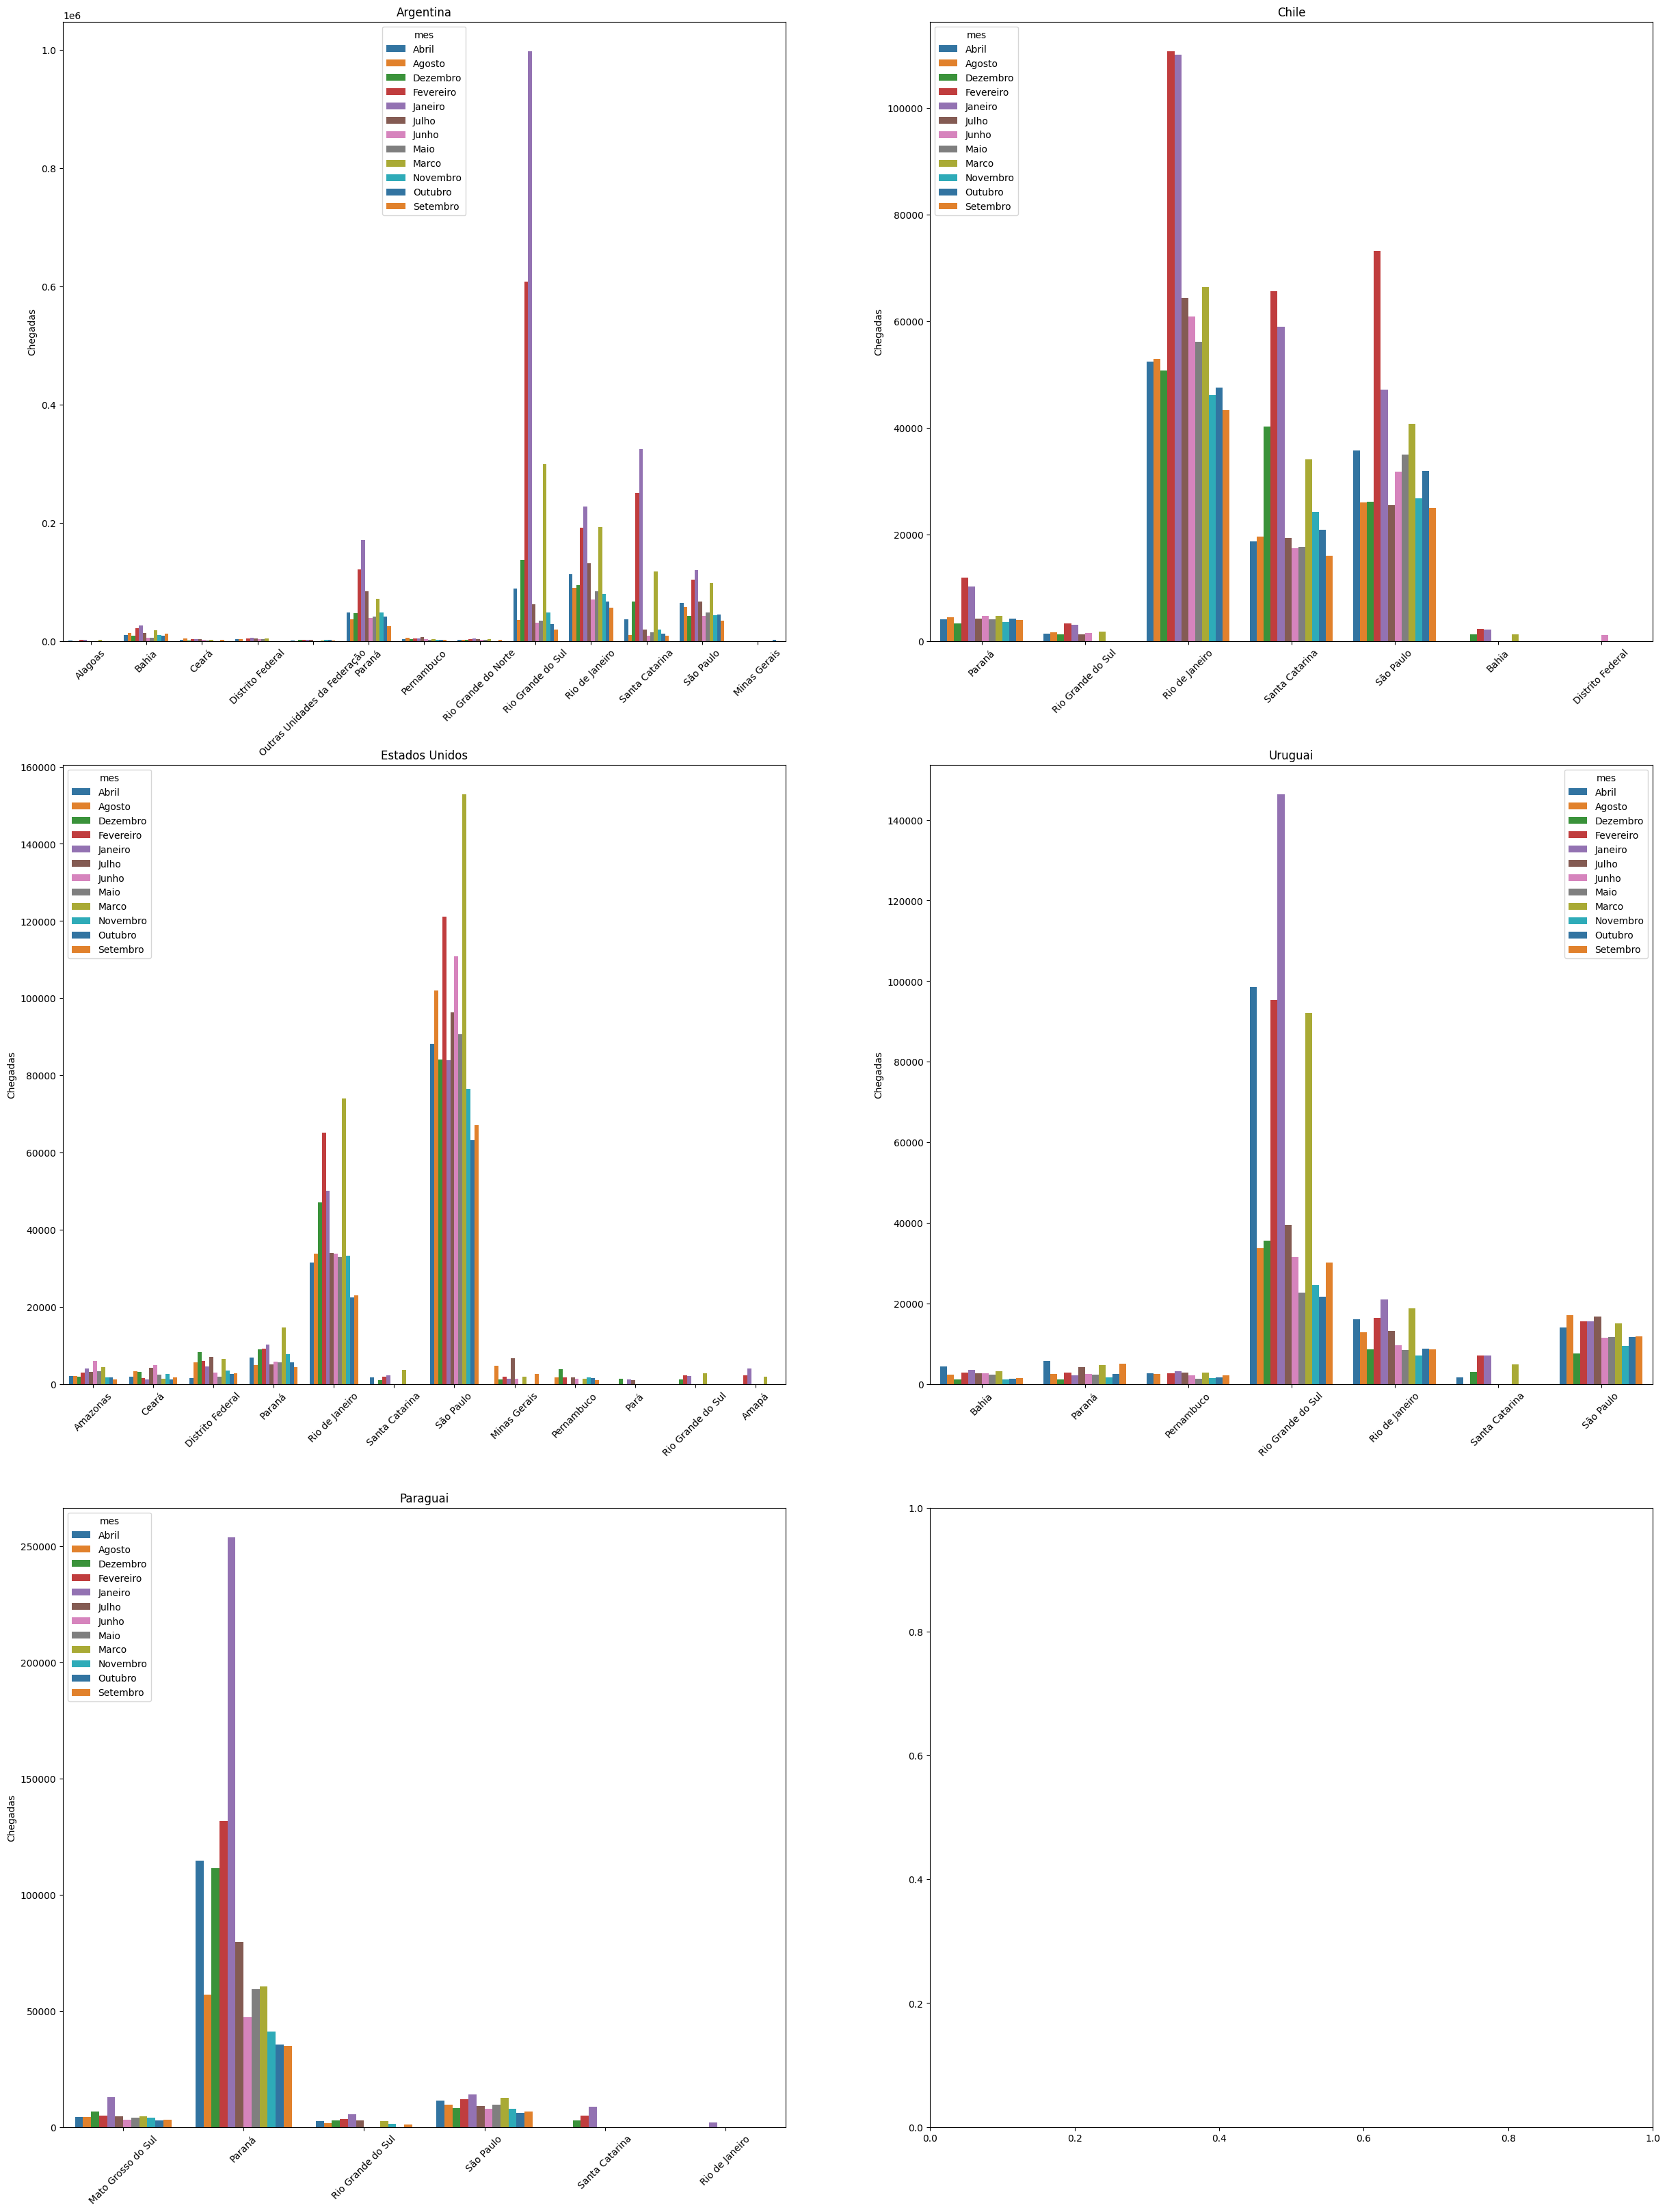

In [46]:
fig,ax = plt.subplots(3,2,figsize=(30,40))

current_country = 0
for i in range(3):
    for j in range(2):
        if(current_country >= len(target_countries)):
            break
        
        country = target_countries[current_country]
        part_data = subdata[(subdata["País"] == country) & (subdata["Chegadas"] > 1000)]

        curr_ax = ax[i,j]
        
        sns.barplot(data=part_data, x="UF", y="Chegadas", hue="mes", ax=curr_ax, palette="tab10")
        curr_ax.set_xticklabels(curr_ax.get_xticklabels(), rotation=45)
        curr_ax.set_title(country)
        curr_ax.set_xlabel("")
        current_country += 1
plt.show()

In [47]:
subdata = grouped_data[(~grouped_data["País"].isin(target_countries)) & (grouped_data["Chegadas"] > 500)]
subdata

,mes,País,UF,Chegadas
13,Abril,Alemanha,Amazonas,624
14,Abril,Alemanha,Bahia,869
15,Abril,Alemanha,Ceará,545
21,Abril,Alemanha,Paraná,4119
23,Abril,Alemanha,Pernambuco,579
...,...,...,...,...
18054,Setembro,Suíça,São Paulo,3686
18126,Setembro,Turquia,São Paulo,5534
18193,Setembro,África do Sul,São Paulo,1875
18211,Setembro,Áustria,São Paulo,1455


In [48]:
subdata["País"].unique()

array(['Alemanha', 'Angola', 'Austrália', 'Bolívia', 'Bulgária',
       'Bélgica', 'Canadá', 'China', 'China, Hong Kong', 'Cingapura',
       'Colômbia', 'Costa Rica', 'Croácia', 'Cuba', 'Dinamarca',
       'El Salvador', 'Equador', 'Espanha', 'Filipinas', 'Finlândia',
       'França', 'Grécia', 'Guatemala', 'Guiana', 'Holanda', 'Honduras',
       'Indonésia', 'Irlanda', 'Israel', 'Itália', 'Japão', 'Marrocos',
       'Moçambique', 'México', 'Noruega', 'Nova Zelândia',
       'Outros países', 'Outros países da África',
       'Outros países da Ásia', 'Panamá', 'Peru', 'Polônia', 'Portugal',
       'Reino Unido', 'República Dominicana', 'República da Coreia',
       'Romênia', 'Rússia', 'Suriname', 'Suécia', 'Suíça', 'Sérvia',
       'Tailândia', 'Taiwan', 'Turquia', 'Ucrânia', 'Venezuela',
       'África do Sul', 'Áustria', 'Índia', 'Hungria', 'Irã',
       'Luxemburgo', 'Nigéria', 'República Tcheca', 'Líbano',
       'Eslováquia', 'Estônia', 'Arábia Saudita', 'Malásia'], dtype=object)

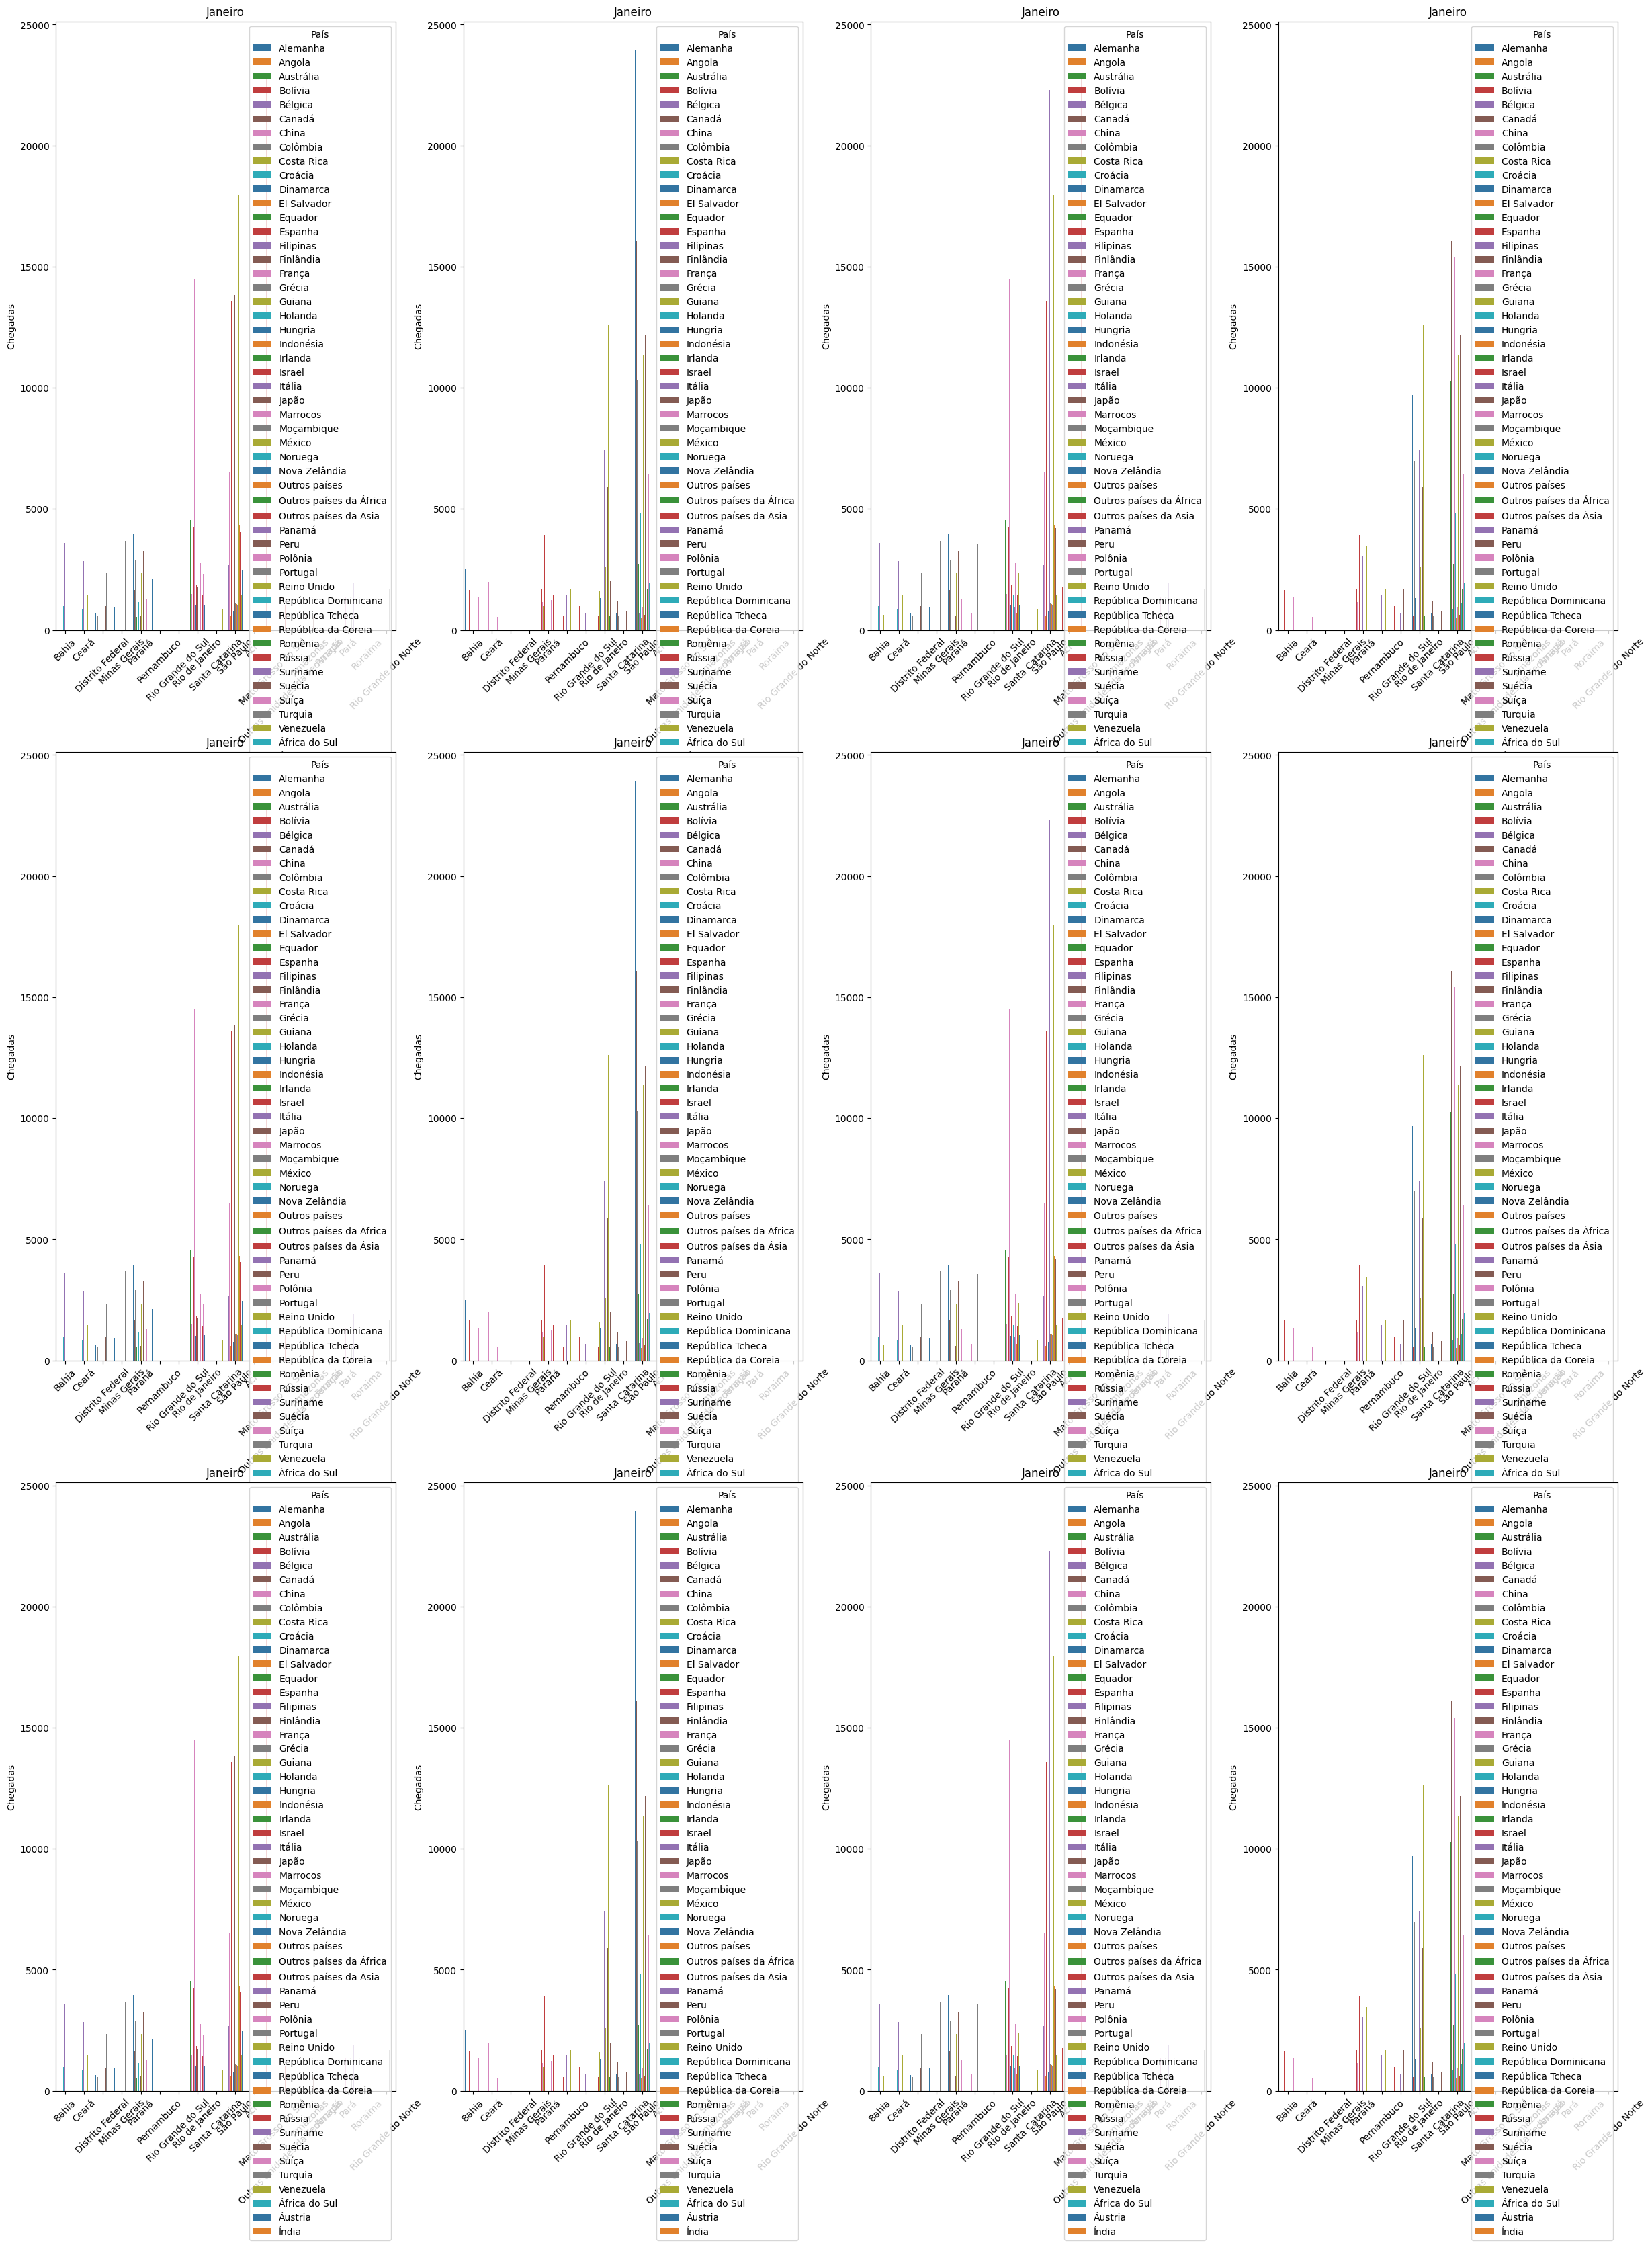

In [49]:
fig,ax = plt.subplots(3,4,figsize=(30,40))

current_month = 0
for i in range(3):
    for j in range(4):
        month = months[current_month]
        
        part_data = subdata[subdata["mes"] == month]

        curr_ax = ax[i,j]
        sns.barplot(data=part_data, x="UF", y="Chegadas", hue="País", ax=curr_ax, palette="tab10")
        curr_ax.set_xticklabels(curr_ax.get_xticklabels(), rotation=45)
        curr_ax.set_title(month)
        curr_ax.set_xlabel("")
        current_country += 1
plt.show()

In [50]:
subdata.describe()


,Chegadas
count,1752.000000
mean,3530.928082
std,4978.099627
min,503.000000
25%,845.000000
50%,1585.500000
75%,3606.000000
max,39908.000000


In [51]:
subdata = grouped_data[(~grouped_data["País"].isin(target_countries)) & (grouped_data["Chegadas"] > 3606)]
subdata.describe()

,Chegadas
count,438.000000
mean,9999.068493
std,6446.752265
min,3621.000000
25%,5009.000000
50%,7539.500000
75%,13445.750000
max,39908.000000


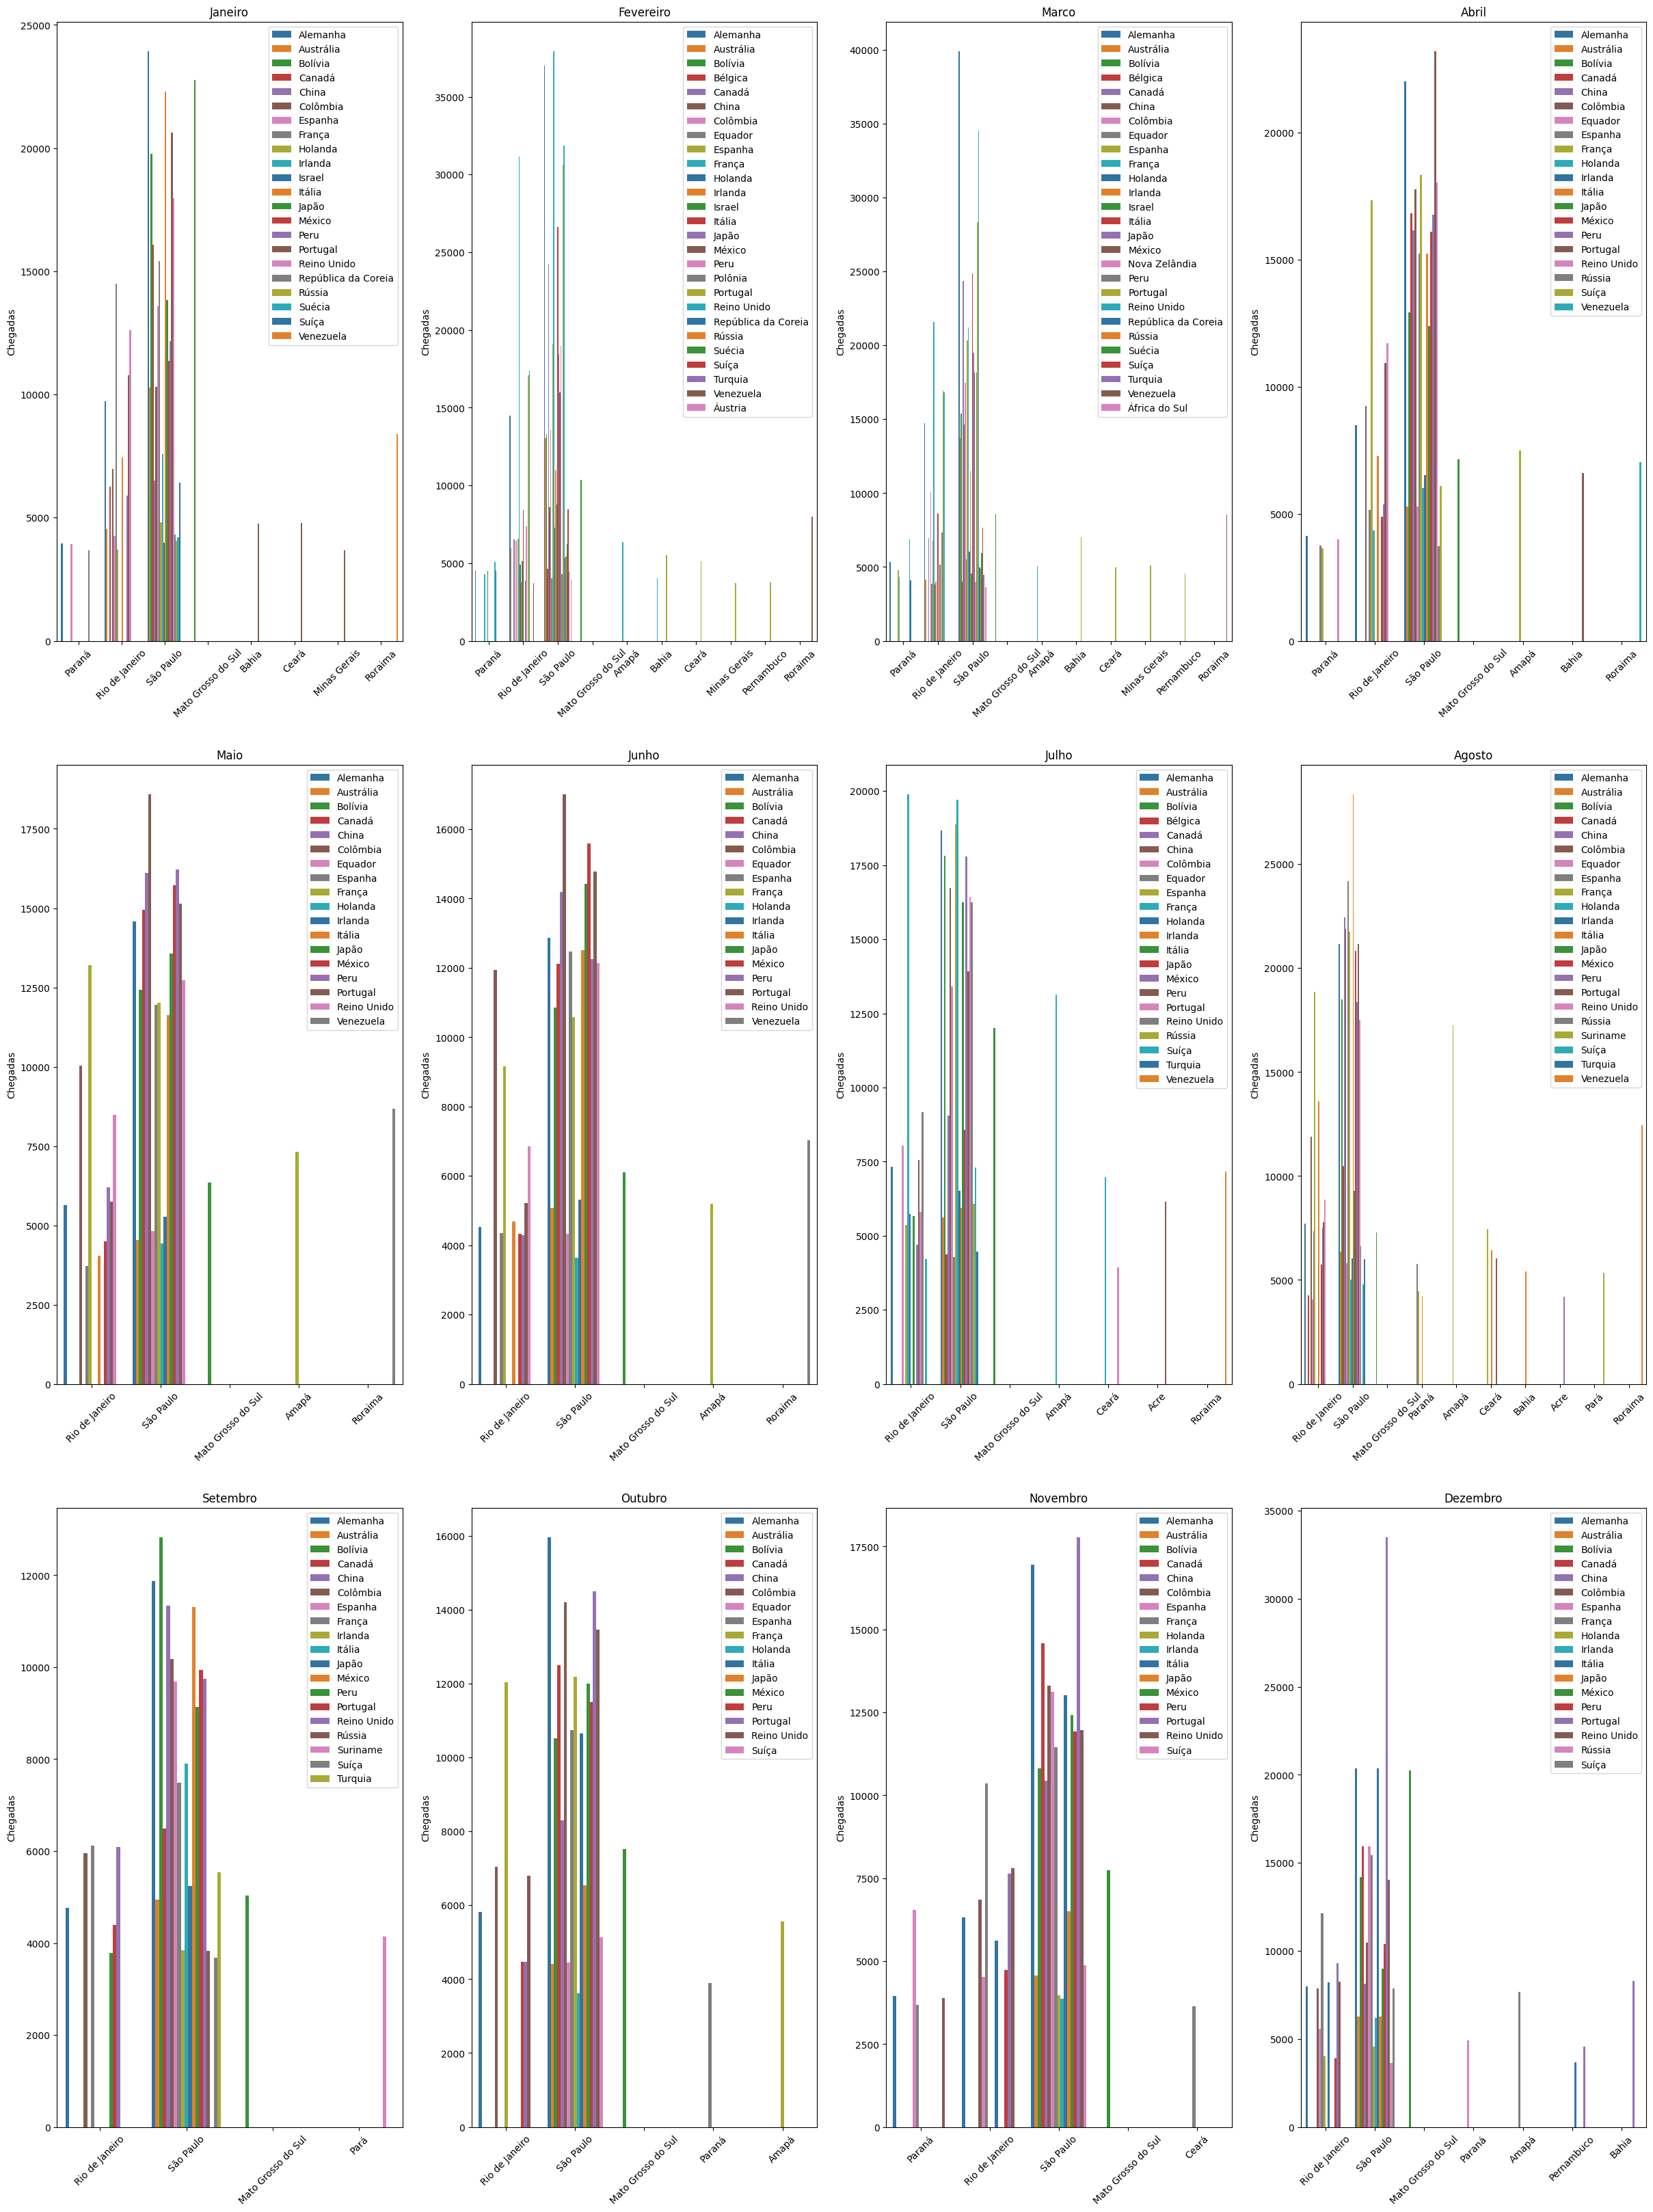

In [52]:
fig,ax = plt.subplots(3,4,figsize=(30,40))

current_month = 0
for i in range(3):
    for j in range(4):
        month = months[current_month]
        
        part_data = subdata[subdata["mes"] == month]

        curr_ax = ax[i,j]
        sns.barplot(data=part_data, x="UF", y="Chegadas", hue="País", ax=curr_ax, palette="tab10")
        curr_ax.set_xticklabels(curr_ax.get_xticklabels(), rotation=45)
        curr_ax.set_title(month)
        curr_ax.set_xlabel("")
        curr_ax.legend(loc='upper right')
        current_month += 1
plt.show()

In [53]:
year_grouped = pd.DataFrame(data.groupby(["País", "ano"])["Chegadas"].sum()).reset_index()
year_grouped.head()

,País,ano,Chegadas
0,Afeganistão,2025,122
1,Albânia,2025,512
2,Alemanha,2023,158582
3,Alemanha,2024,182166
4,Alemanha,2025,132636


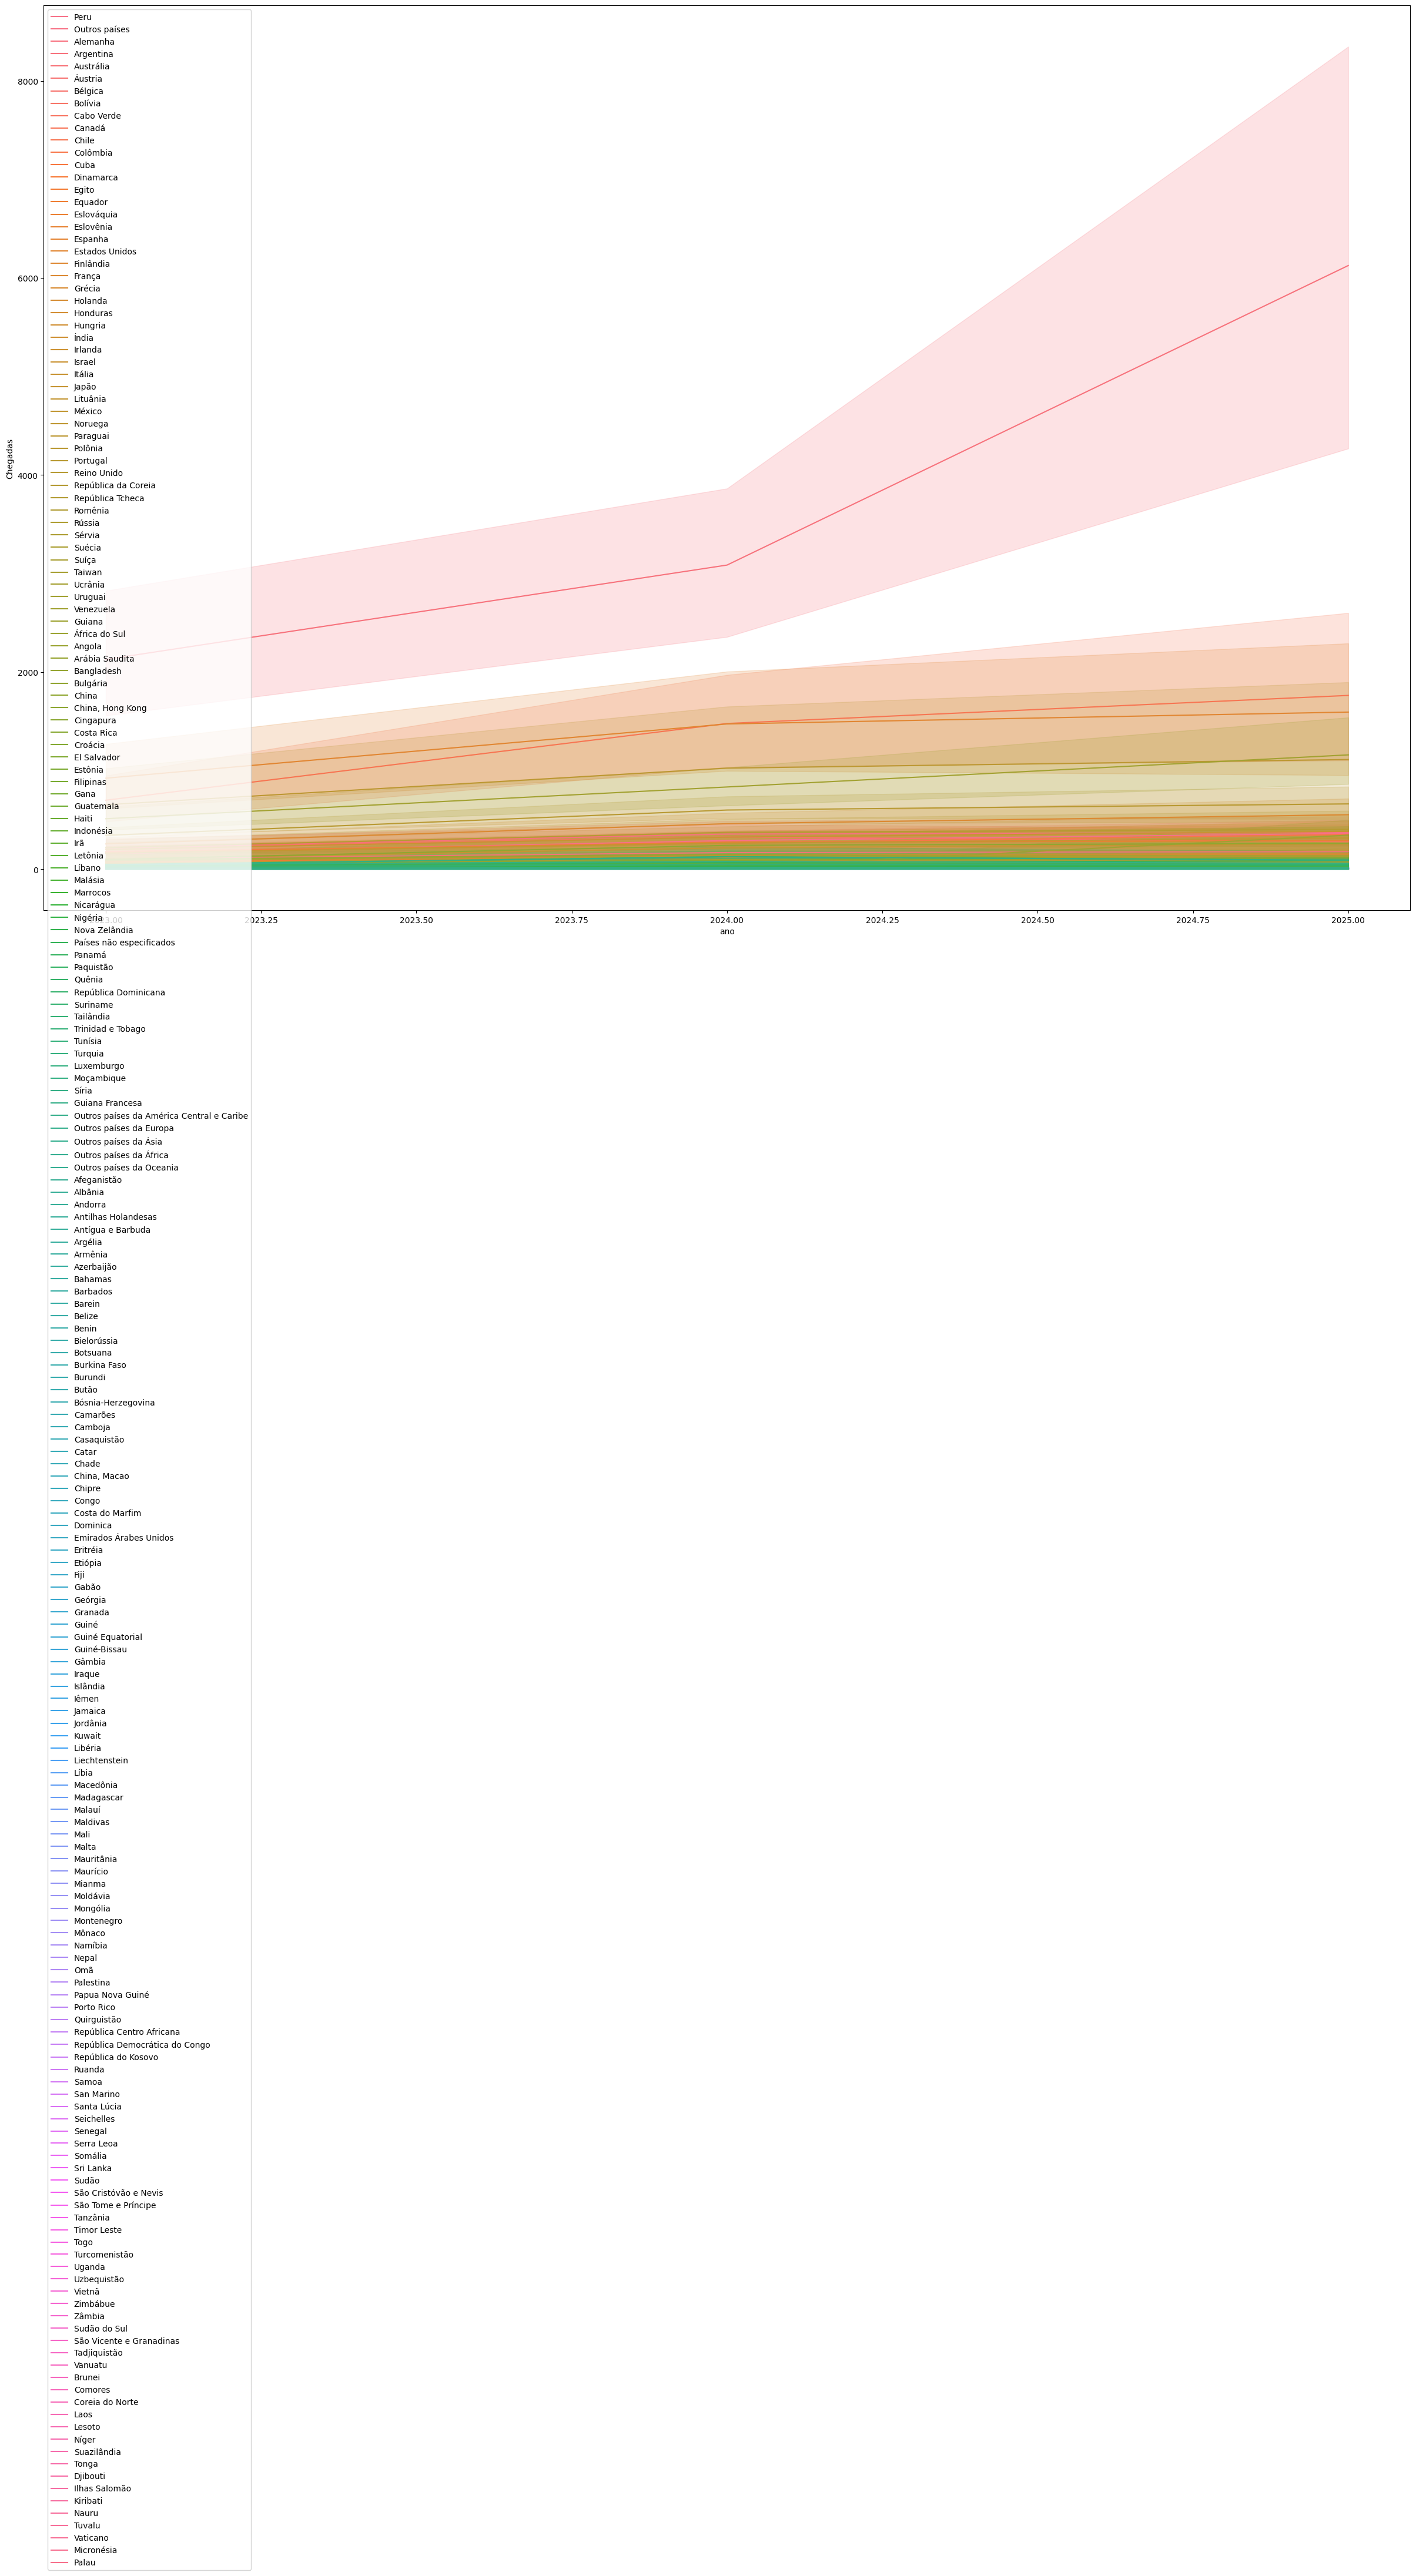

In [54]:
plt.figure(figsize=(30,20))
sns.lineplot(data=data, x="ano", y="Chegadas", hue="País")
plt.legend(loc="upper left")
plt.show()

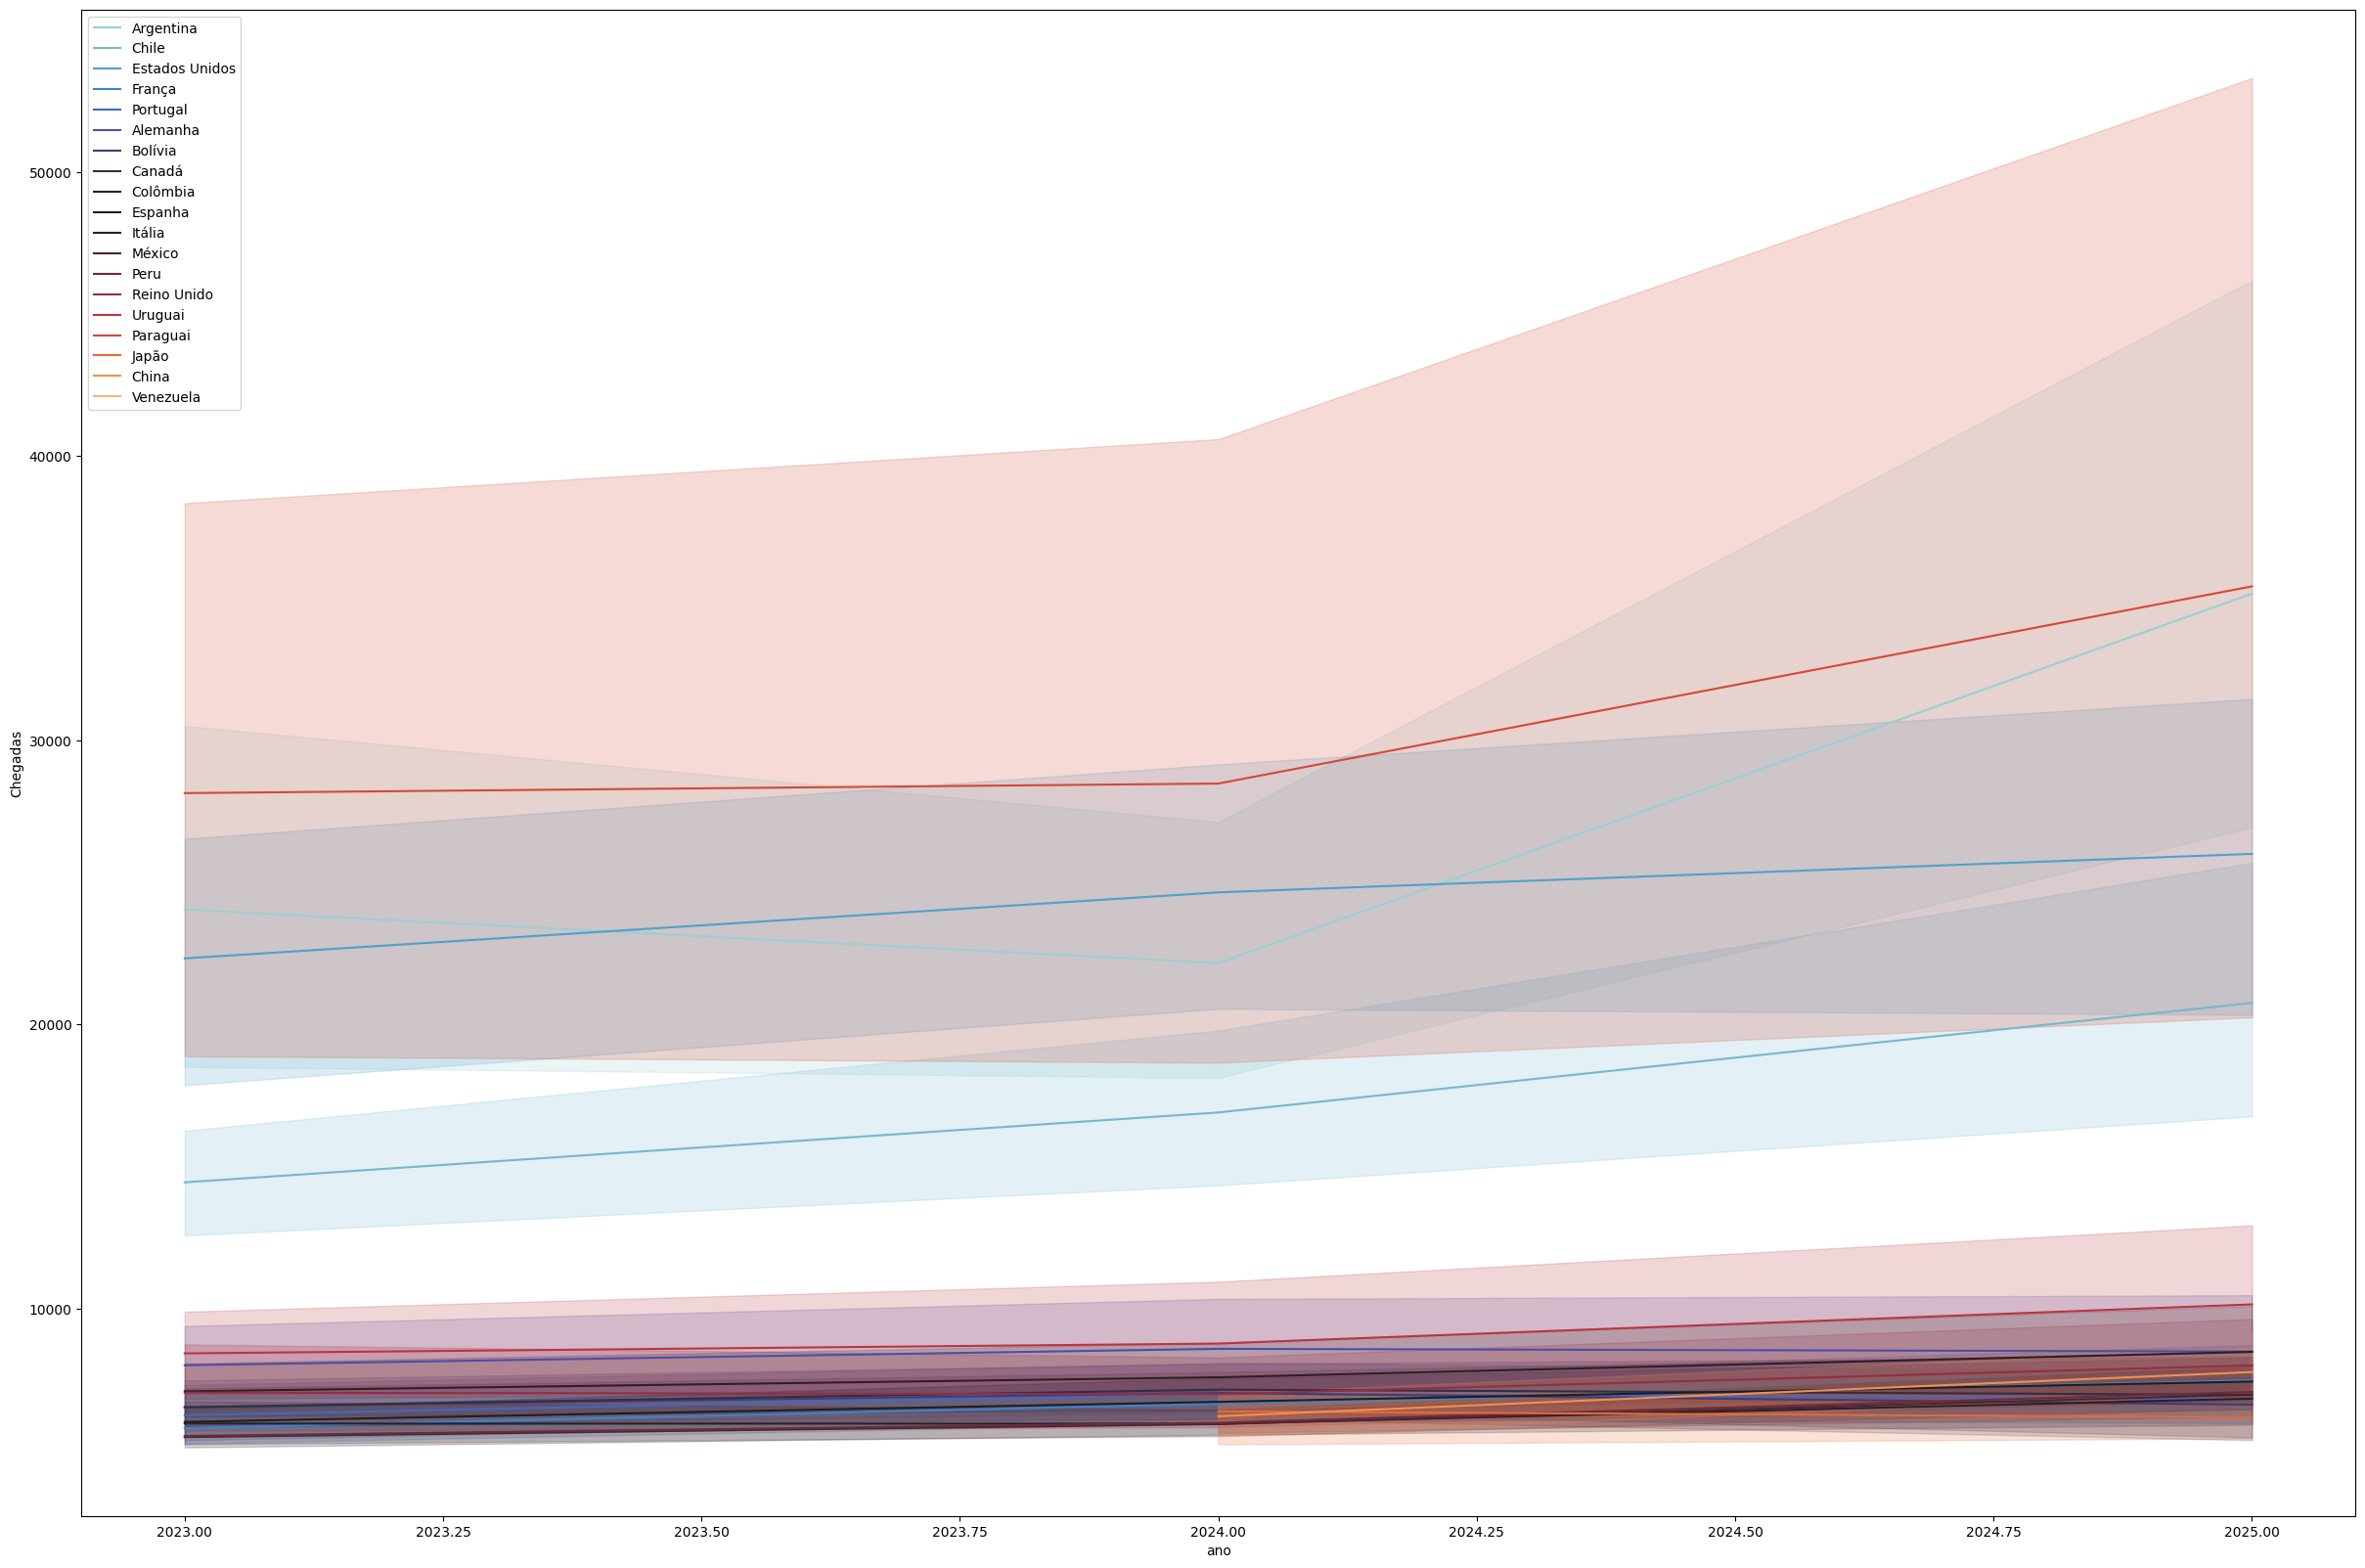

In [55]:
subdata = data[data["Chegadas"] > 5000]
plt.figure(figsize=(30,20))
sns.lineplot(data=subdata, x="ano", y="Chegadas", hue="País", palette="icefire")
plt.legend(loc="upper left")
plt.show()

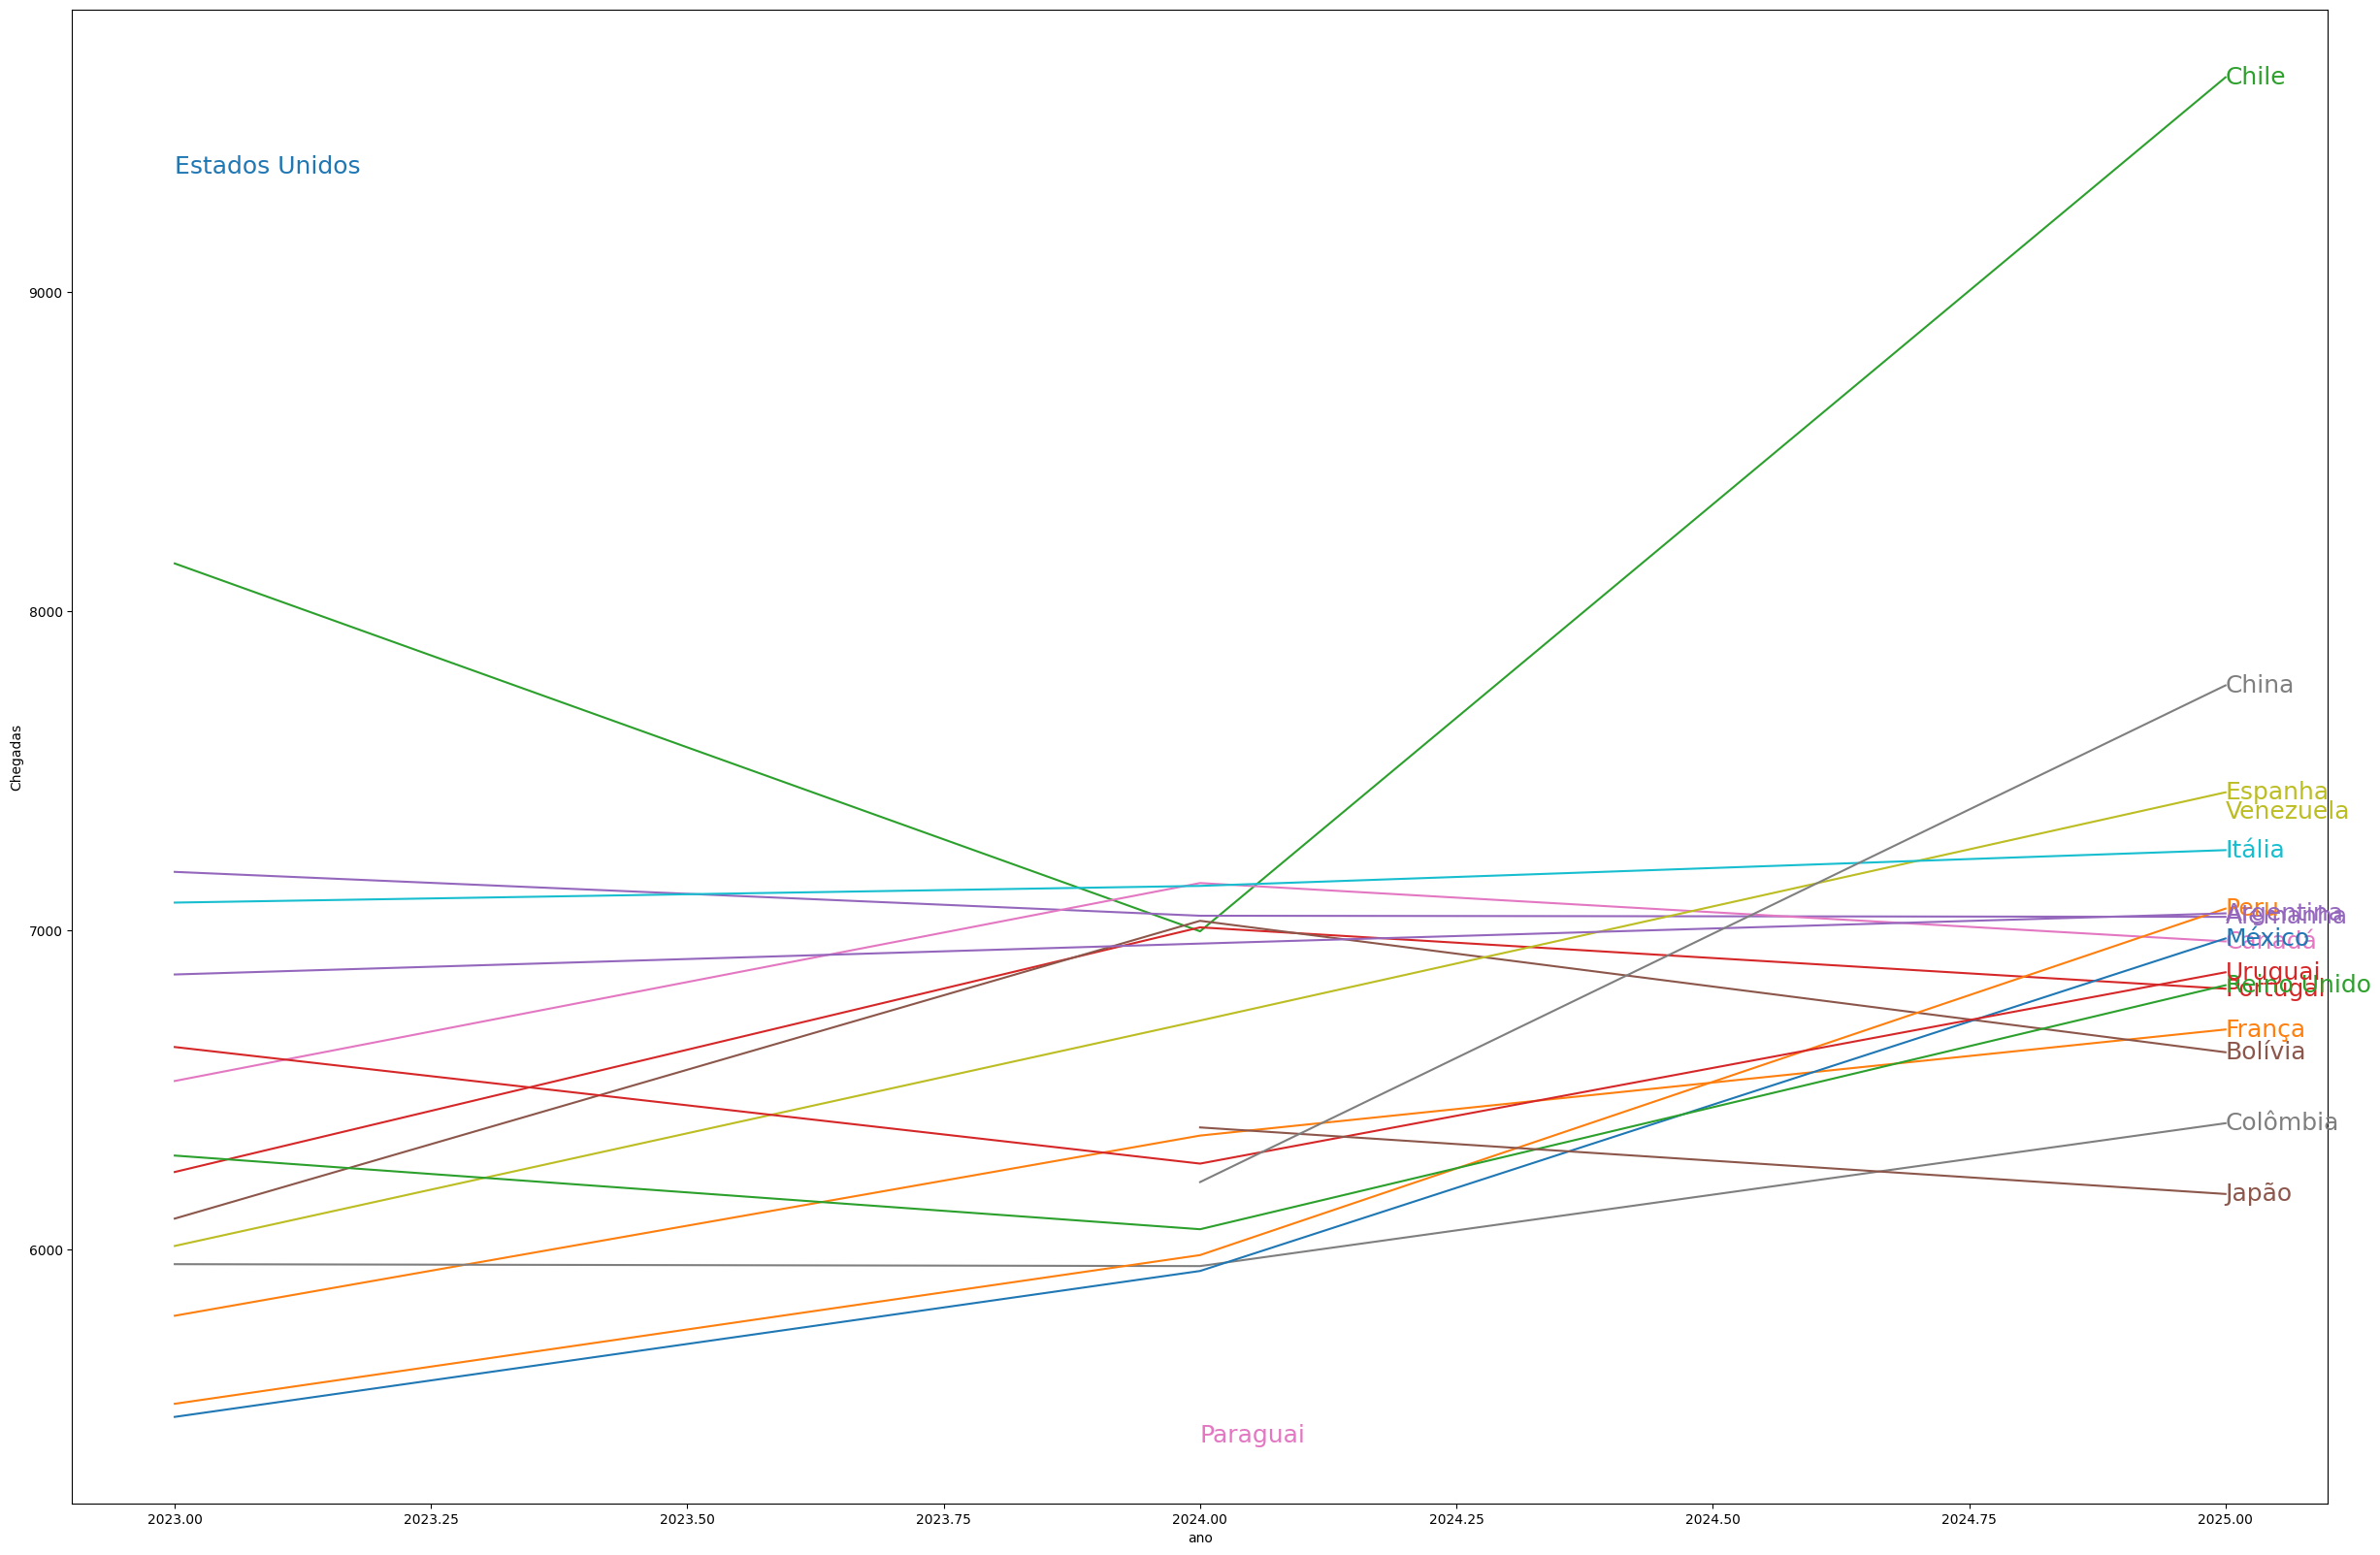

In [56]:
subdata = data[(data["Chegadas"] > 5000) & (data["Chegadas"] <= 10000)]
plt.figure(figsize=(30,20))
plot = sns.lineplot(data=subdata, x="ano", y="Chegadas", hue="País", palette="tab10",legend=False,errorbar=None)

for line, name in zip(plot.lines, subdata['País'].unique()):
    y_last = line.get_ydata()[-1]
    x_last = line.get_xdata()[-1]
    plot.text(x_last, y_last, name, color=line.get_color(), va='center', ha='left', fontsize=18)
plt.show()